full eda workflow using youtube tredding video dataset

In [25]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,8)

In [26]:
# Load your dataset
df = pd.read_csv("trending_videos.csv")

# Returns a new DataFrame without NaN in 'tags'
df = df.dropna(subset=['tags'])




# Show first rows
df.head()

,video_id,title,title_length,has_caps_title,has_emoji_title,has_question_title,channel_name,subscriber_count,channel_verified,category,...,comment_view_ratio_pct,engagement_score,tags,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
0,VID000001,This survival challenge is UNREAL,33,1,0,0,FireShorts,197893,0,Comedy,...,0.4058,3.8514,adventure|prank|Netflix|Python|space|documenta...,10,500,1,0.664,1,1,0
1,VID000002,Learn Quantum Physics - Complete Beginner Guide,47,0,0,0,FireSports,16191,0,Education,...,0.2300,4.2700,unboxing|Olympics|space|podcast|minecraft|musi...,10,500,1,0.394,1,0,0
2,VID000003,I Spent $1000 on AI tools,25,1,0,0,TruePlus,170530,1,Entertainment,...,1.7400,10.2000,fitness|nature|crypto|unboxing|motivation|NBA ...,7,150,1,0.537,1,1,0
3,VID000004,Ice | Doja Cat ft. Post Malone,30,0,0,0,ProChannel,31268,1,Music,...,0.2400,9.5500,2026|fortnite|PS5,3,300,0,0.552,1,1,0
4,VID000005,The Future of VR is HERE,24,1,0,0,MoonClips,130507,1,Science & Technology,...,0.6640,9.3277,stable diffusion|fortnite|laptop|tech,4,50,0,0.323,1,1,0


In [27]:
# Shape
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns)

# Data types
df.info()

# Summary stats
df.describe()

Shape: (10000, 34)
Columns: Index(['video_id', 'title', 'title_length', 'has_caps_title',
       'has_emoji_title', 'has_question_title', 'channel_name',
       'subscriber_count', 'channel_verified', 'category', 'publish_date',
       'trending_date', 'days_to_trend', 'year', 'month', 'day_of_week',
       'trending_country', 'language', 'duration_seconds', 'views', 'likes',
       'dislikes', 'comments', 'like_view_ratio_pct', 'comment_view_ratio_pct',
       'engagement_score', 'tags', 'tag_count', 'description_length',
       'has_links_description', 'clickbait_score', 'comments_enabled',
       'caption_available', 'made_for_kids'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                10000 non-null  object 
 1   title                   10000 non-null  object 
 2   title_l

,title_length,has_caps_title,has_emoji_title,has_question_title,subscriber_count,channel_verified,days_to_trend,year,month,duration_seconds,...,like_view_ratio_pct,comment_view_ratio_pct,engagement_score,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,32.292800,0.656700,0.029700,0.012600,2.930864e+06,0.399200,2.96720,2022.643300,6.339700,763.870600,...,5.598921,0.661010,7.581951,8.437000,778.790000,0.590500,0.455631,0.924300,0.650500,0.02520
std,6.029453,0.474834,0.169767,0.111546,1.604973e+07,0.489758,3.18109,1.809915,3.500047,933.412373,...,3.118135,0.468657,3.441650,3.433018,1113.631067,0.491766,0.195576,0.264531,0.476836,0.15674
min,18.000000,0.000000,0.000000,0.000000,1.000000e+03,0.000000,0.00000,2020.000000,1.000000,15.000000,...,0.181900,0.000000,0.318300,3.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.00000
25%,28.000000,0.000000,0.000000,0.000000,3.141800e+04,0.000000,1.00000,2021.000000,3.000000,259.000000,...,3.286625,0.317175,5.064950,5.000000,150.000000,0.000000,0.307000,1.000000,0.000000,0.00000
50%,32.000000,1.000000,0.000000,0.000000,1.659430e+05,0.000000,2.00000,2023.000000,6.000000,447.000000,...,5.052150,0.556700,7.076400,8.000000,300.000000,1.000000,0.455000,1.000000,1.000000,0.00000
75%,37.000000,1.000000,0.000000,0.000000,8.914365e+05,1.000000,5.00000,2024.000000,9.000000,925.000000,...,7.320000,0.888950,9.550275,11.000000,1000.000000,1.000000,0.600000,1.000000,1.000000,0.00000
max,53.000000,1.000000,1.000000,1.000000,3.000000e+08,1.000000,14.00000,2026.000000,12.000000,20425.000000,...,24.950000,4.120000,28.182400,14.000000,5000.000000,1.000000,0.973000,1.000000,1.000000,1.00000


In [28]:
# Missing values
df.isnull().sum()



video_id                  0
title                     0
title_length              0
has_caps_title            0
has_emoji_title           0
has_question_title        0
channel_name              0
subscriber_count          0
channel_verified          0
category                  0
publish_date              0
trending_date             0
days_to_trend             0
year                      0
month                     0
day_of_week               0
trending_country          0
language                  0
duration_seconds          0
views                     0
likes                     0
dislikes                  0
comments                  0
like_view_ratio_pct       0
comment_view_ratio_pct    0
engagement_score          0
tags                      0
tag_count                 0
description_length        0
has_links_description     0
clickbait_score           0
comments_enabled          0
caption_available         0
made_for_kids             0
dtype: int64

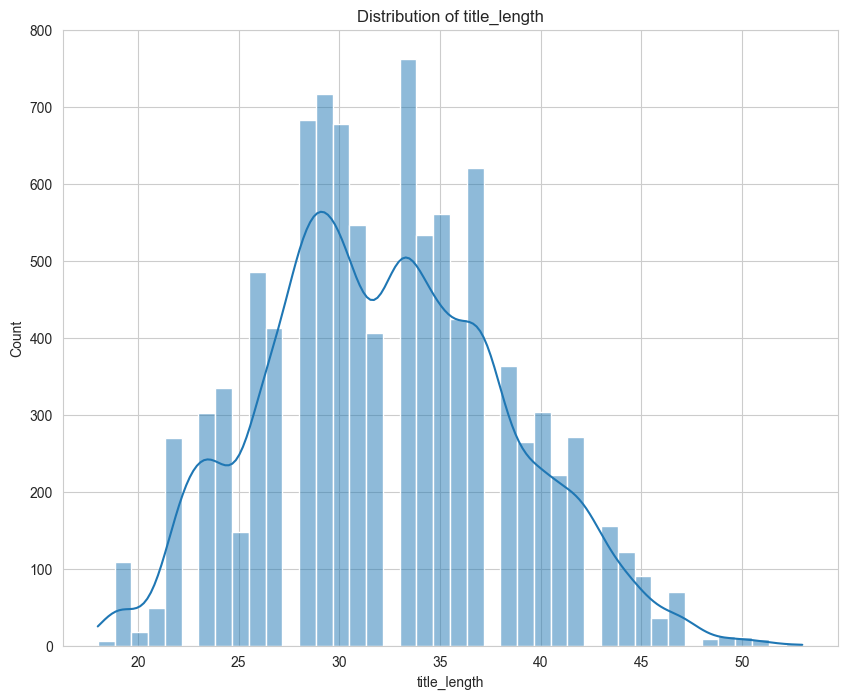

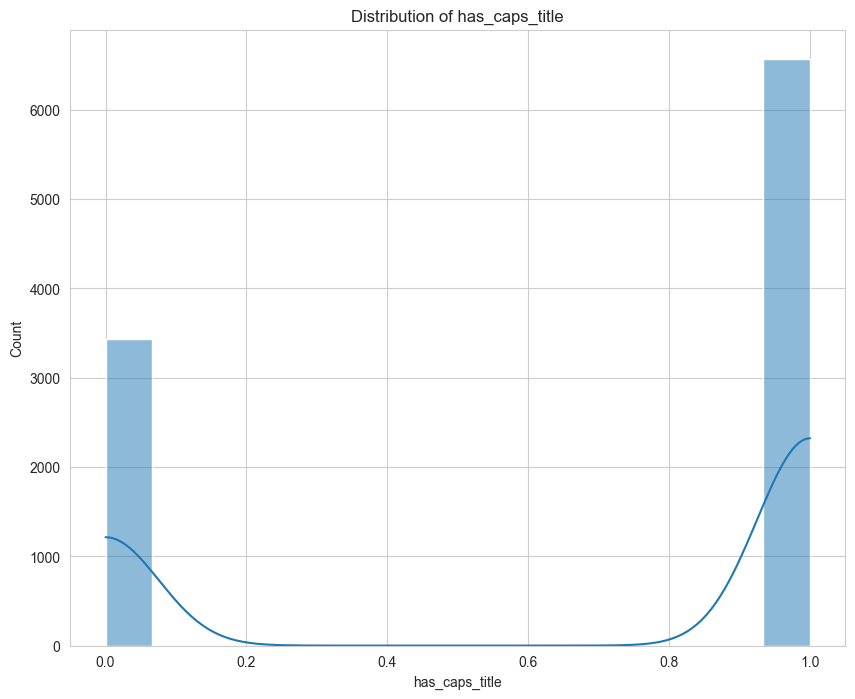

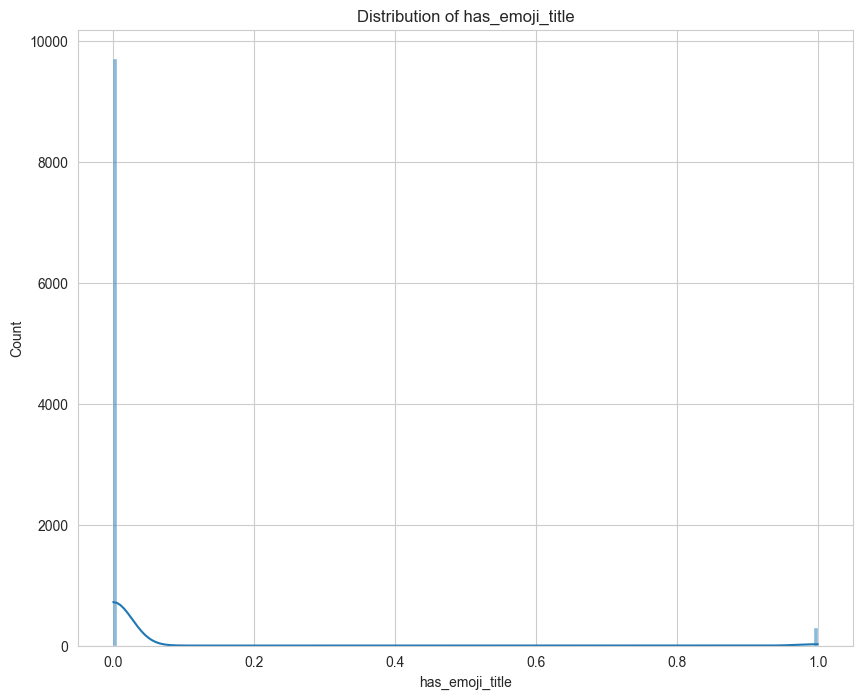

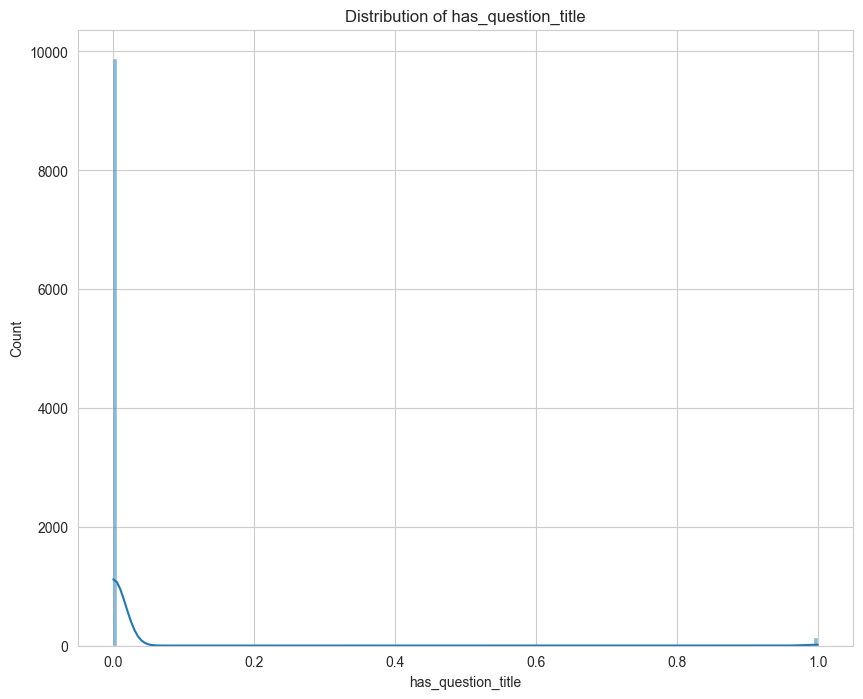

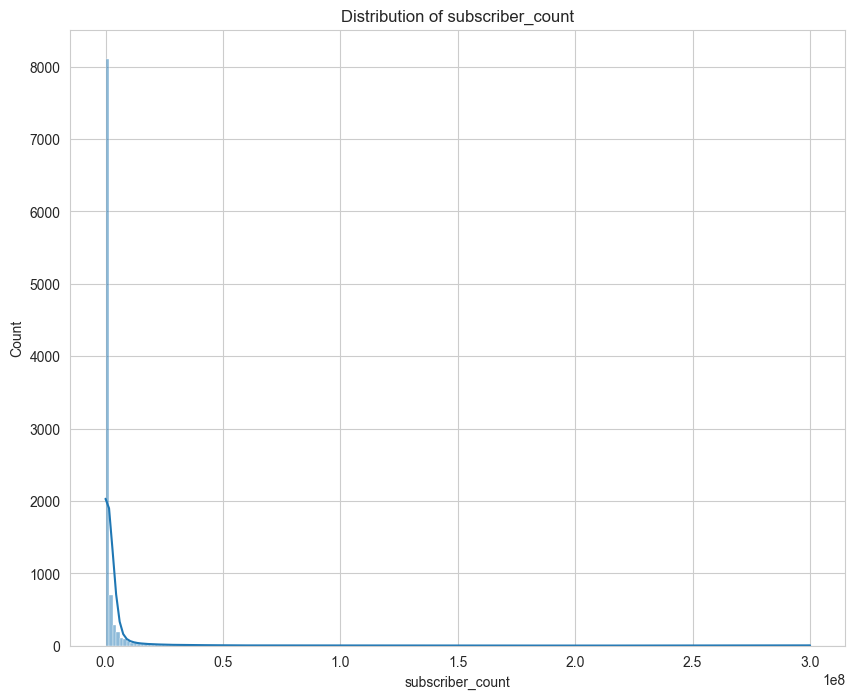

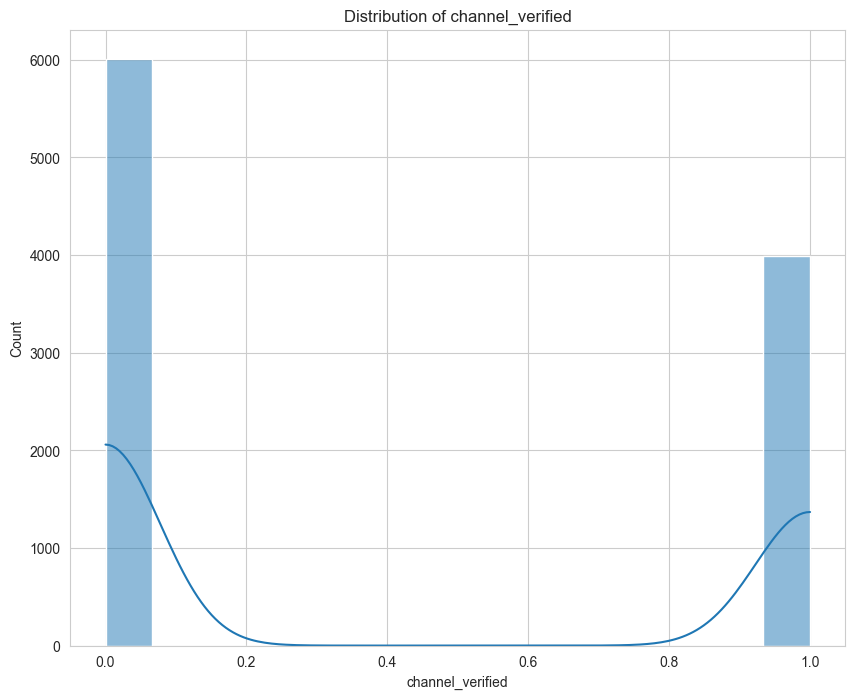

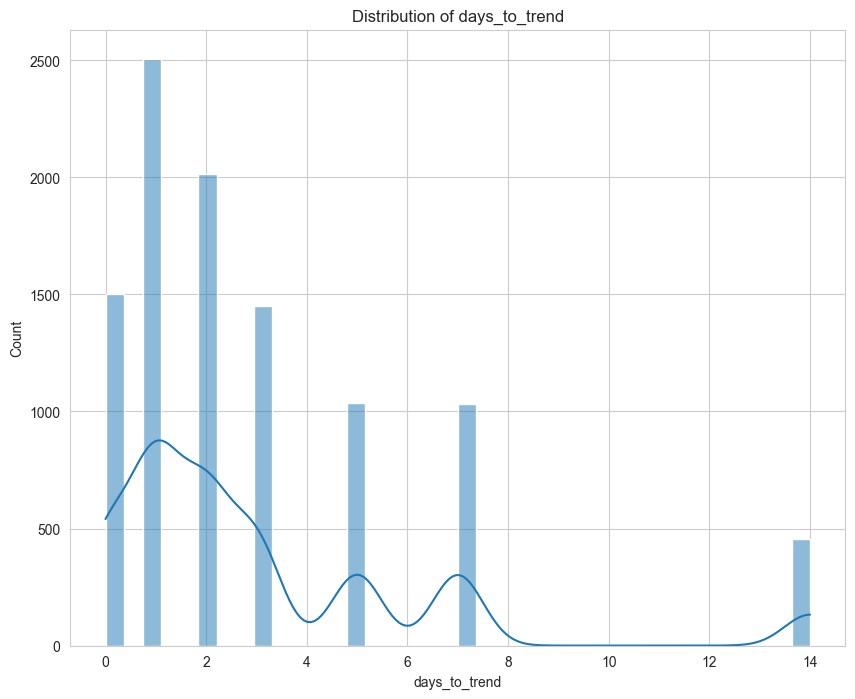

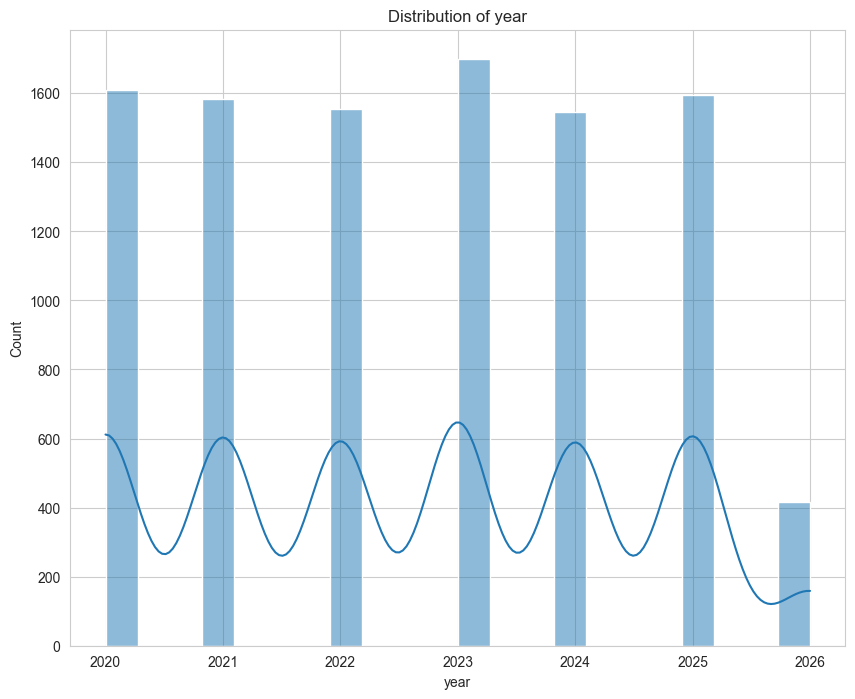

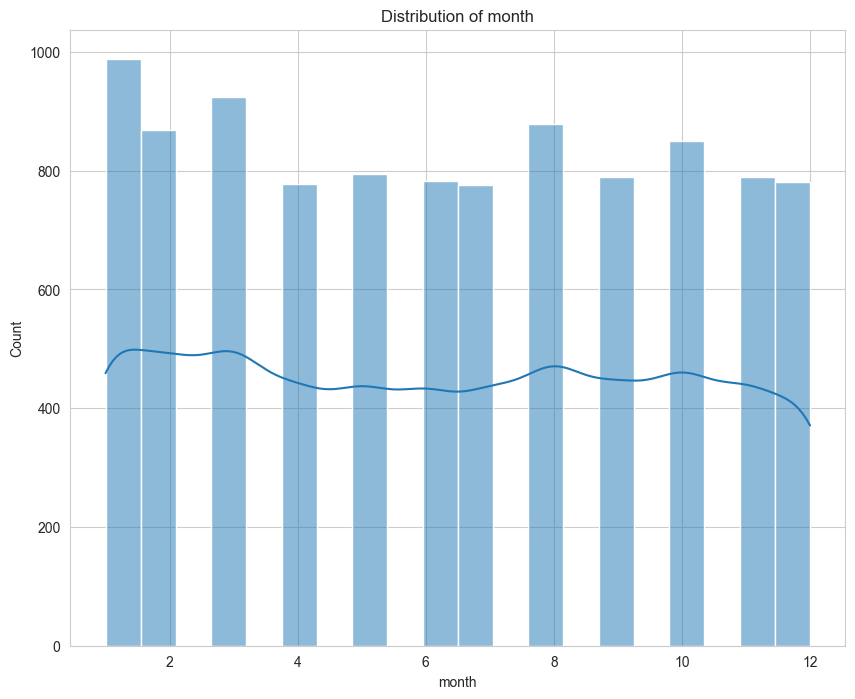

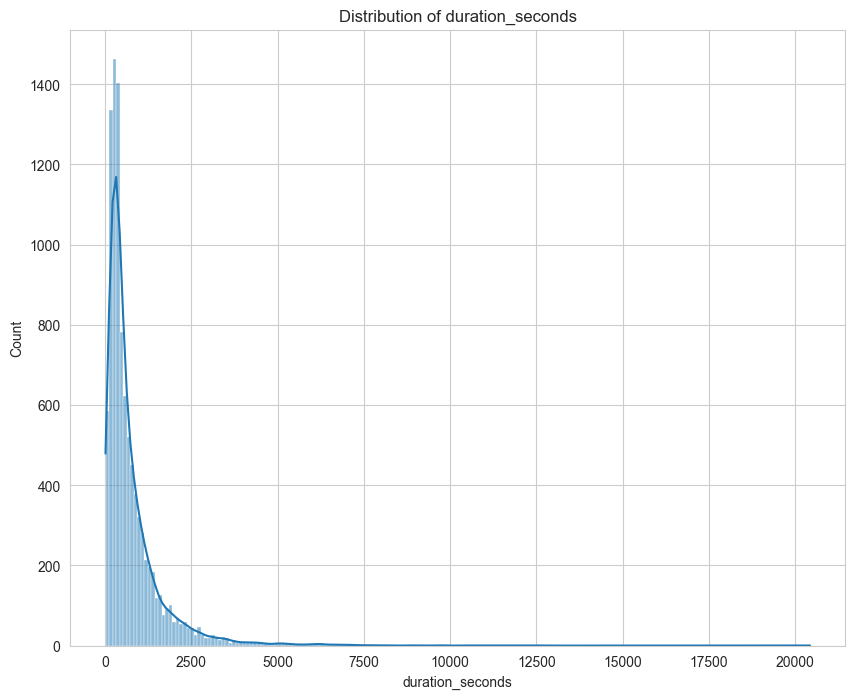

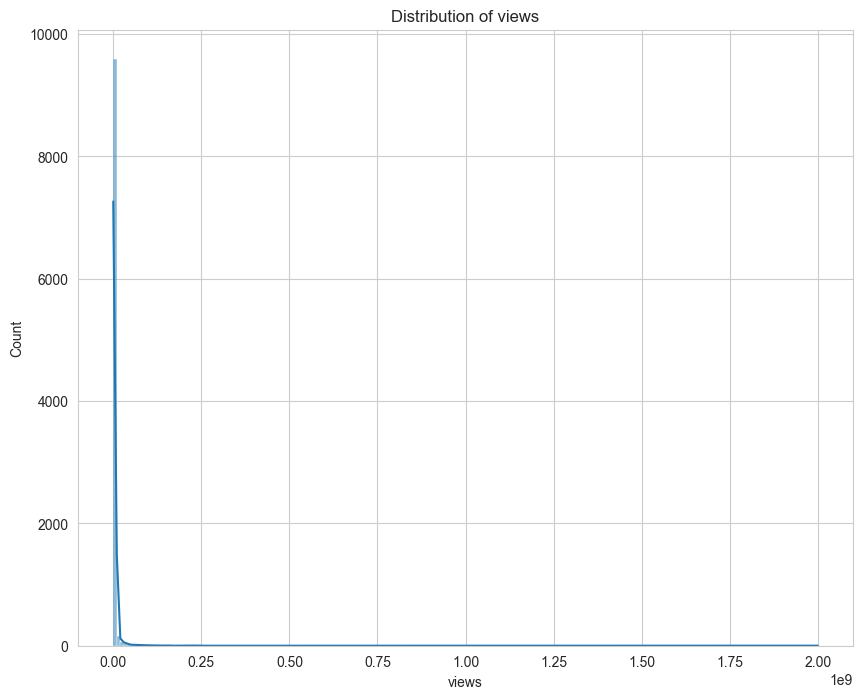

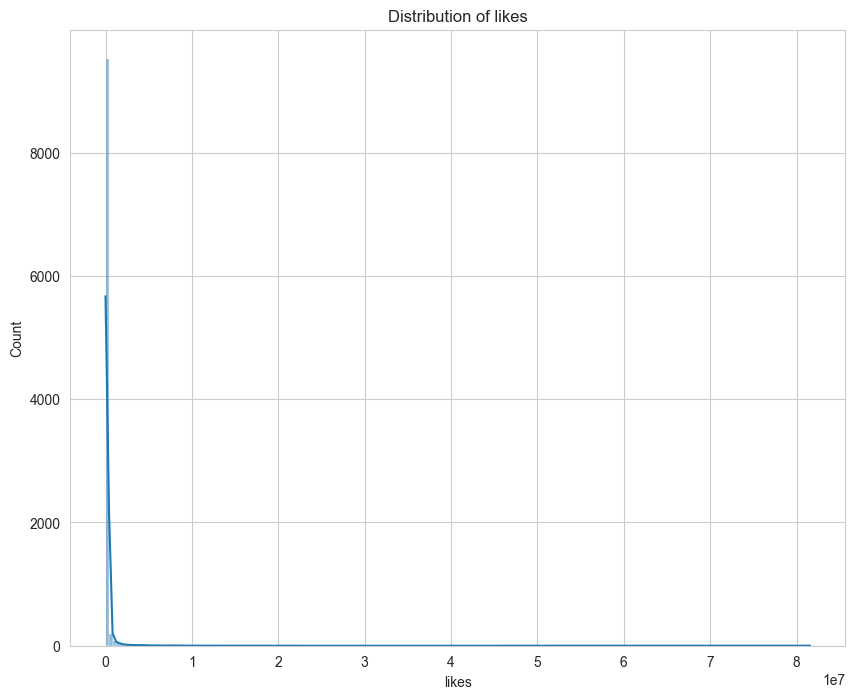

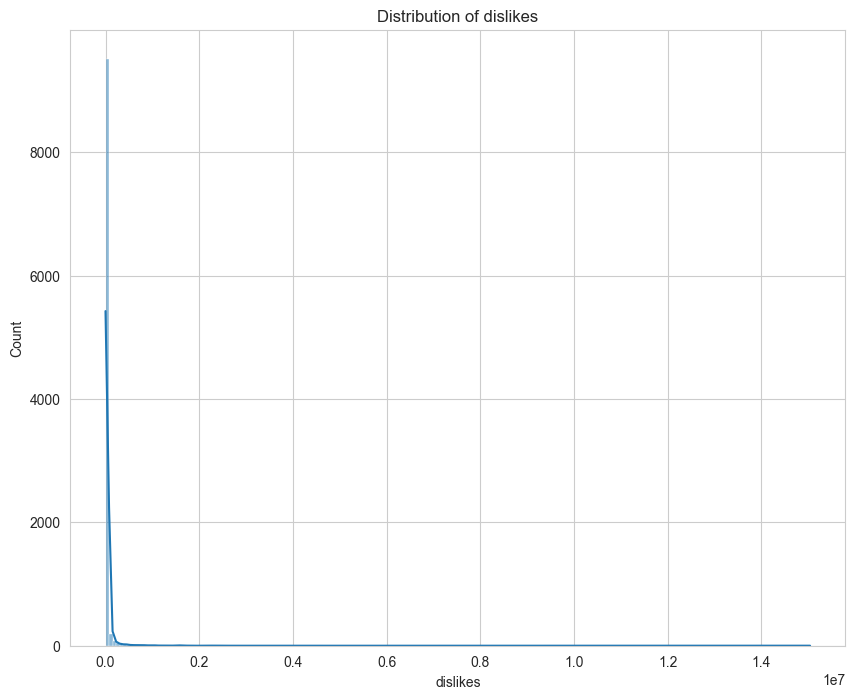

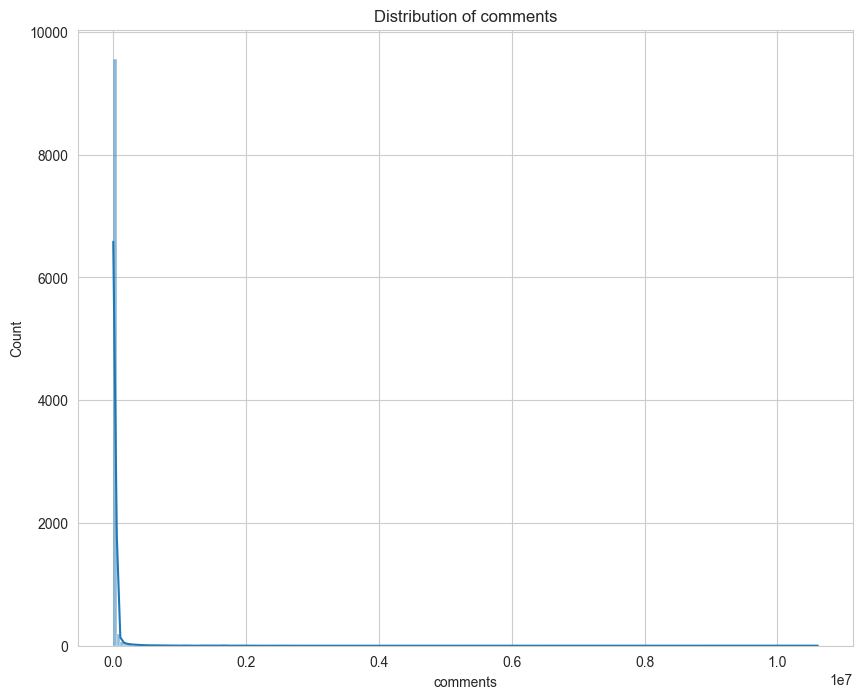

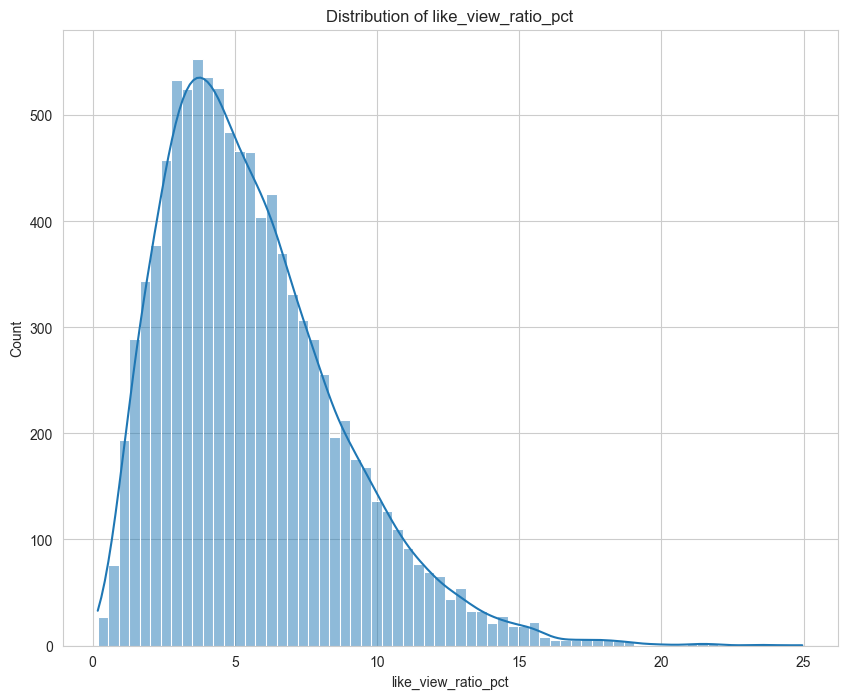

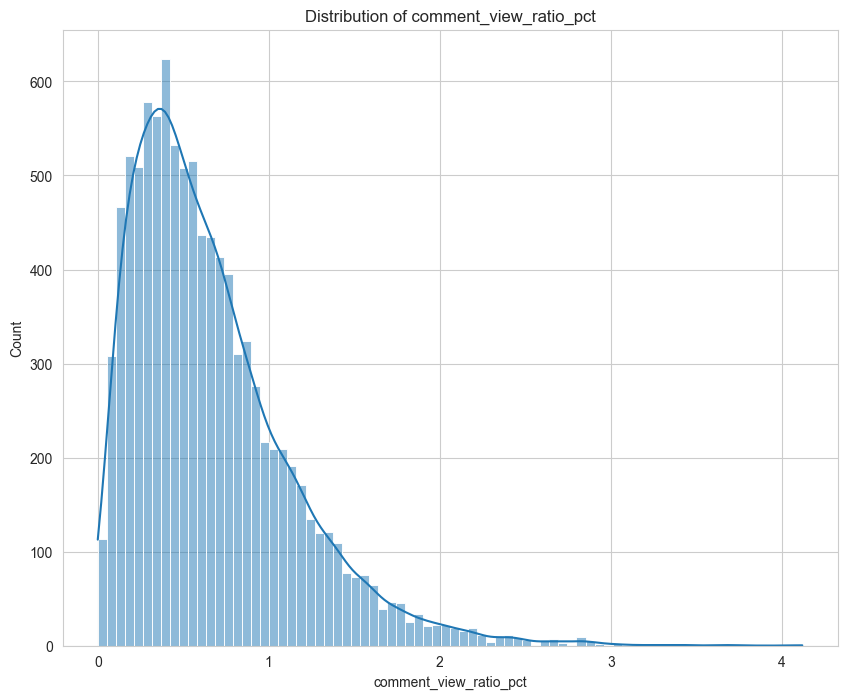

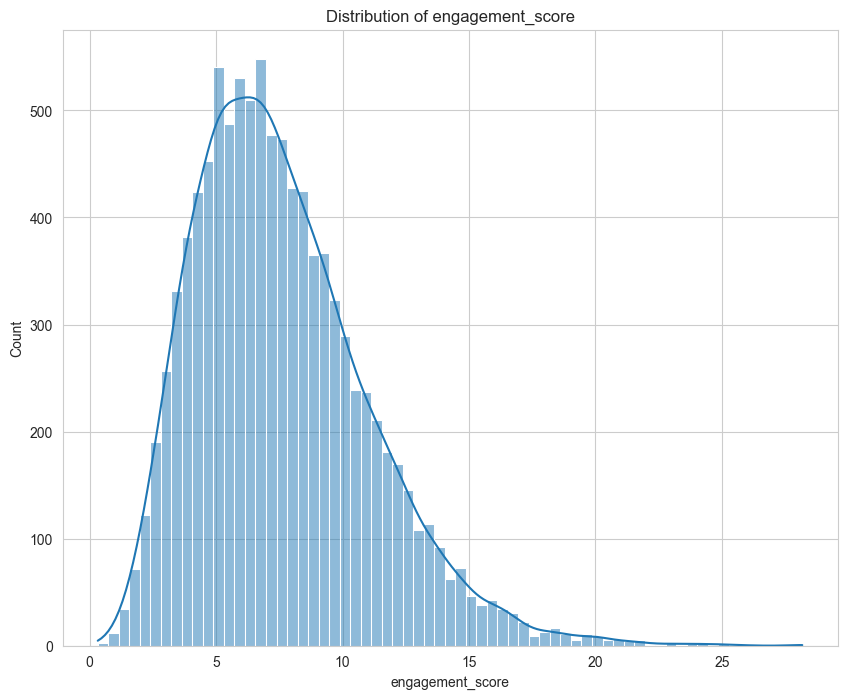

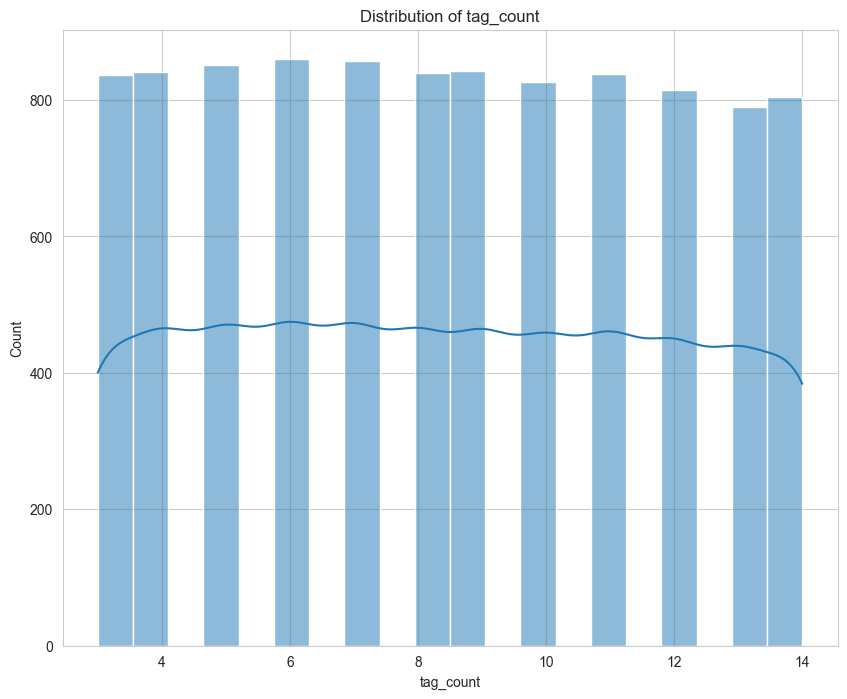

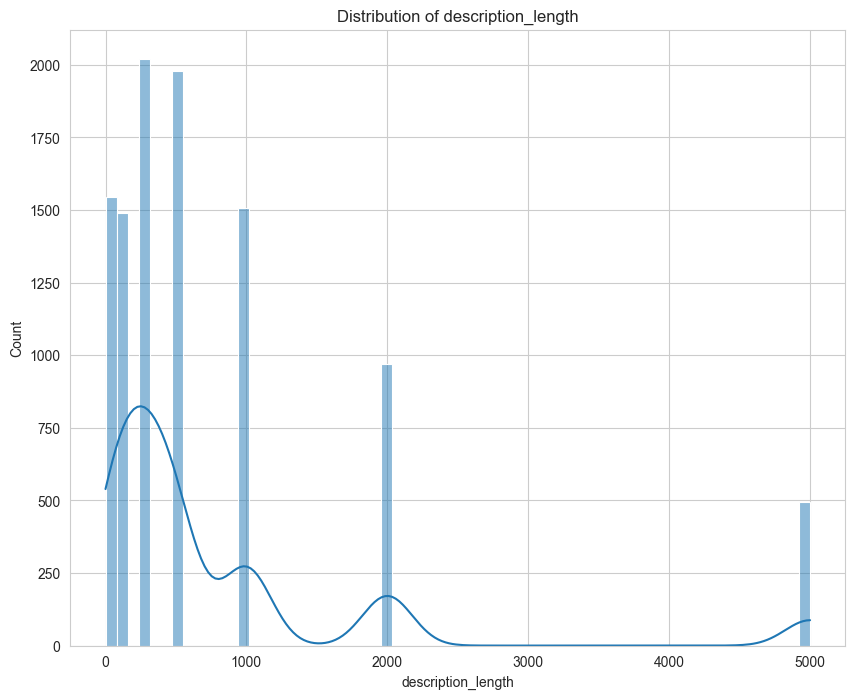

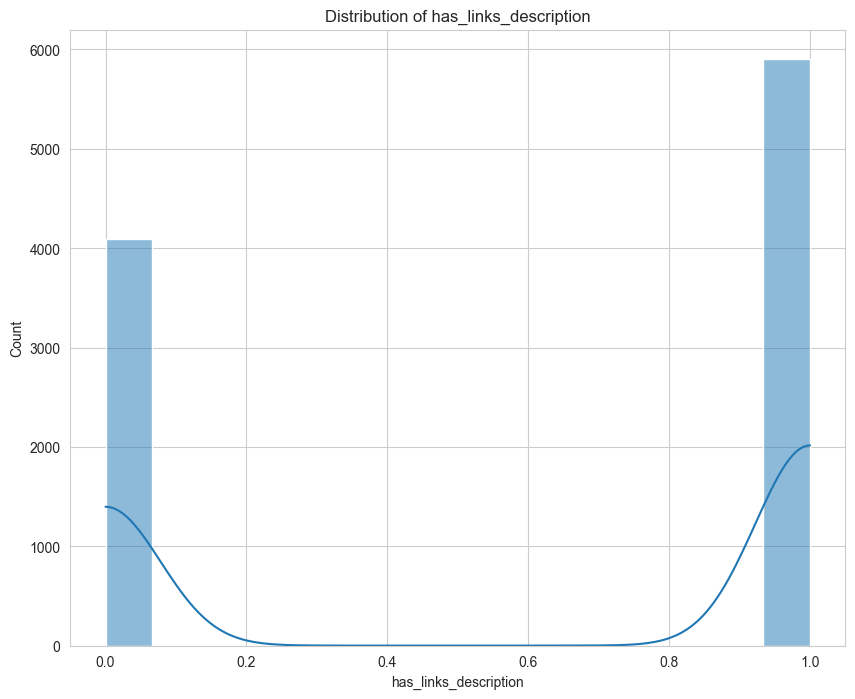

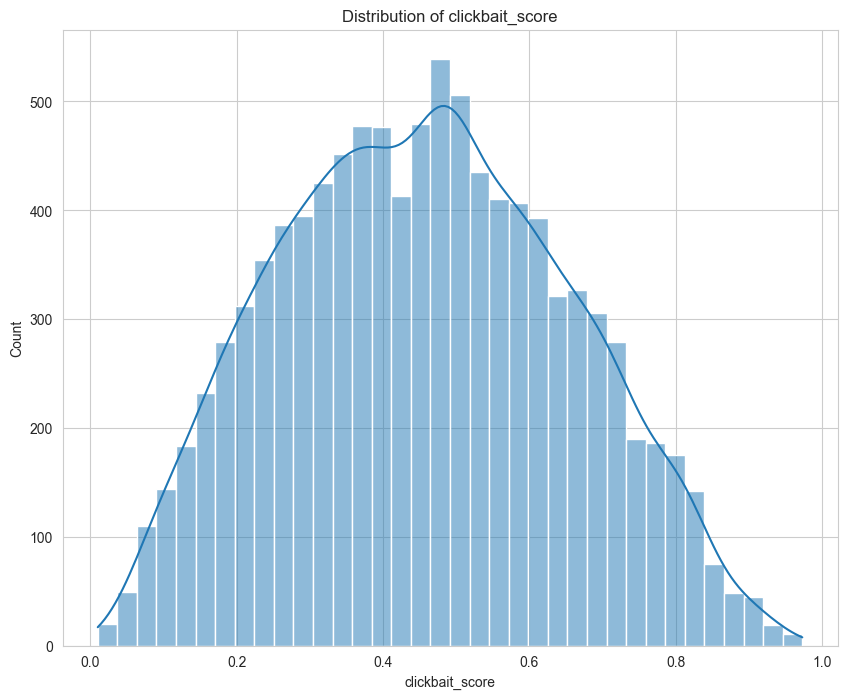

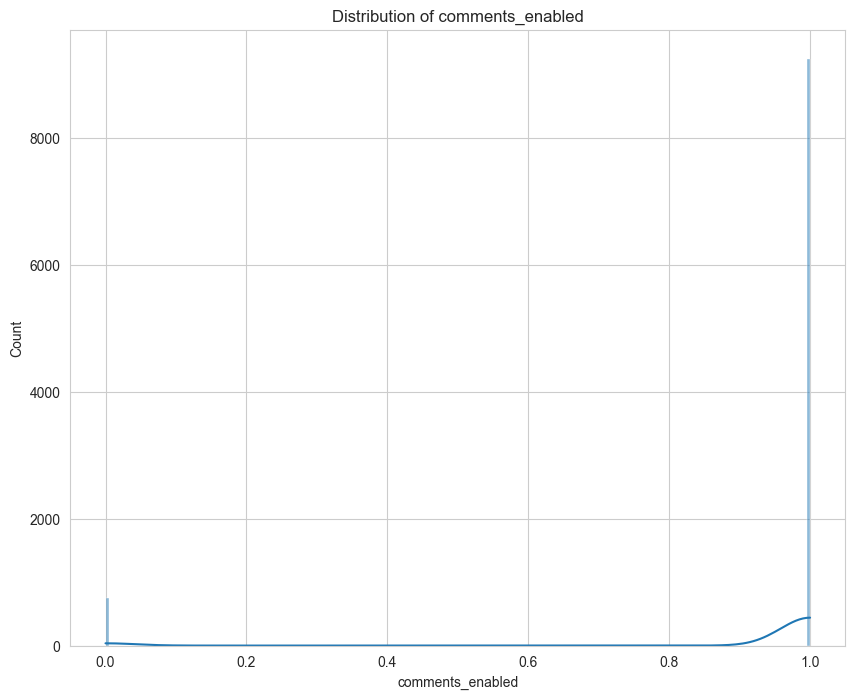

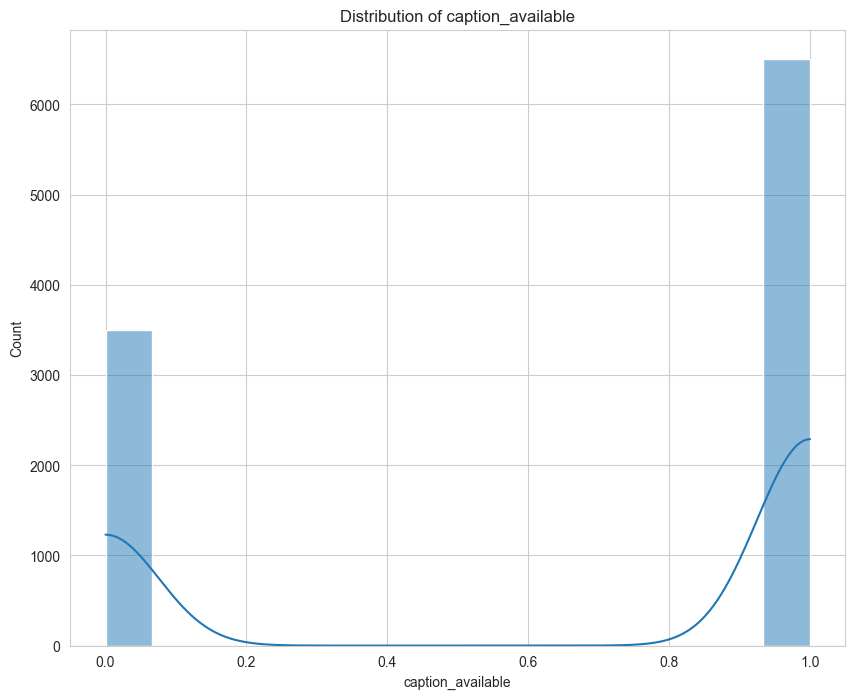

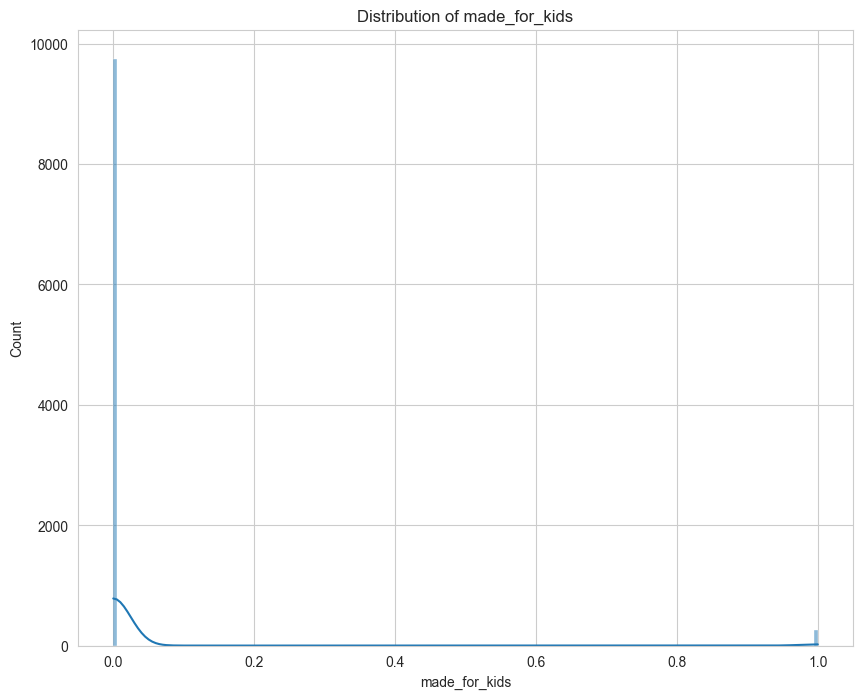

In [29]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    
    plt.show()

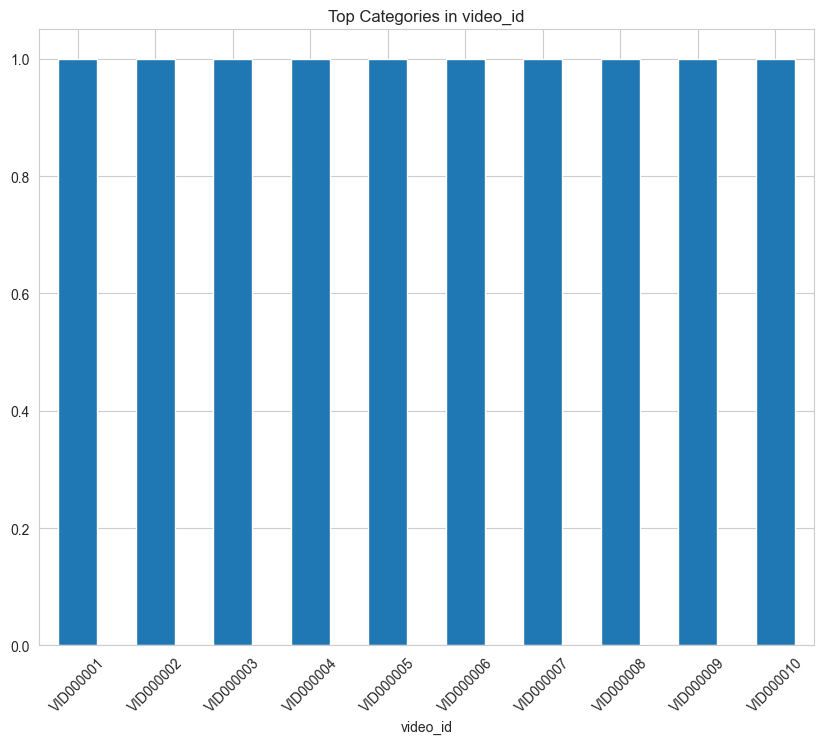

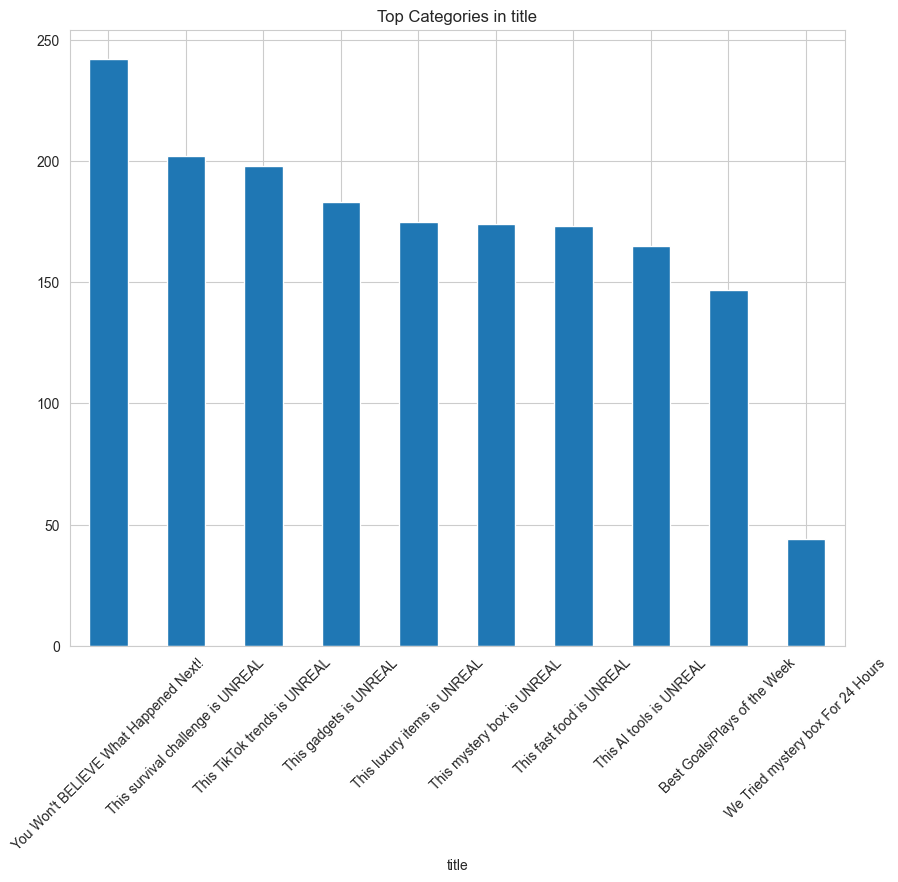

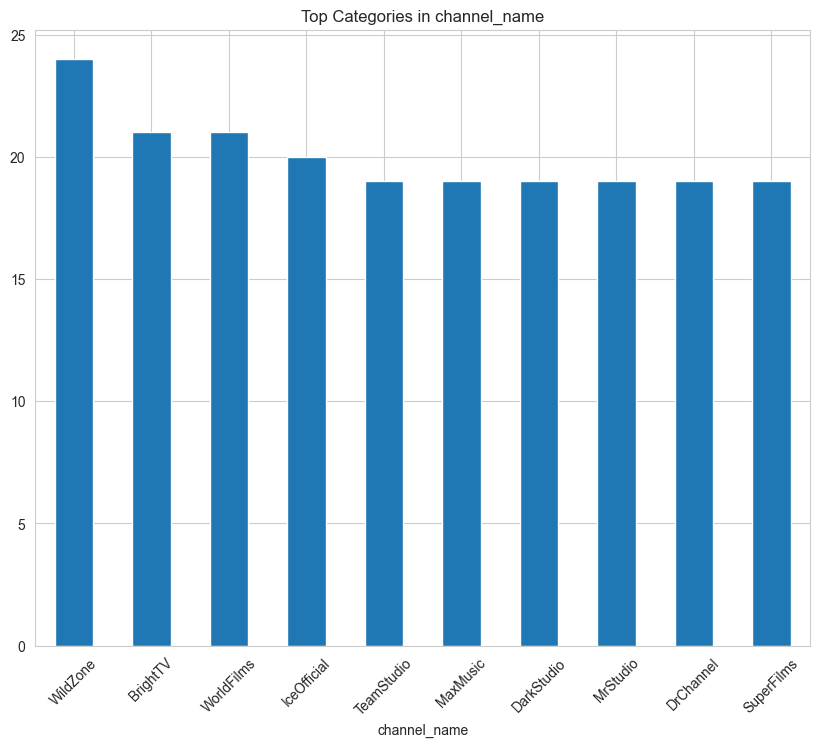

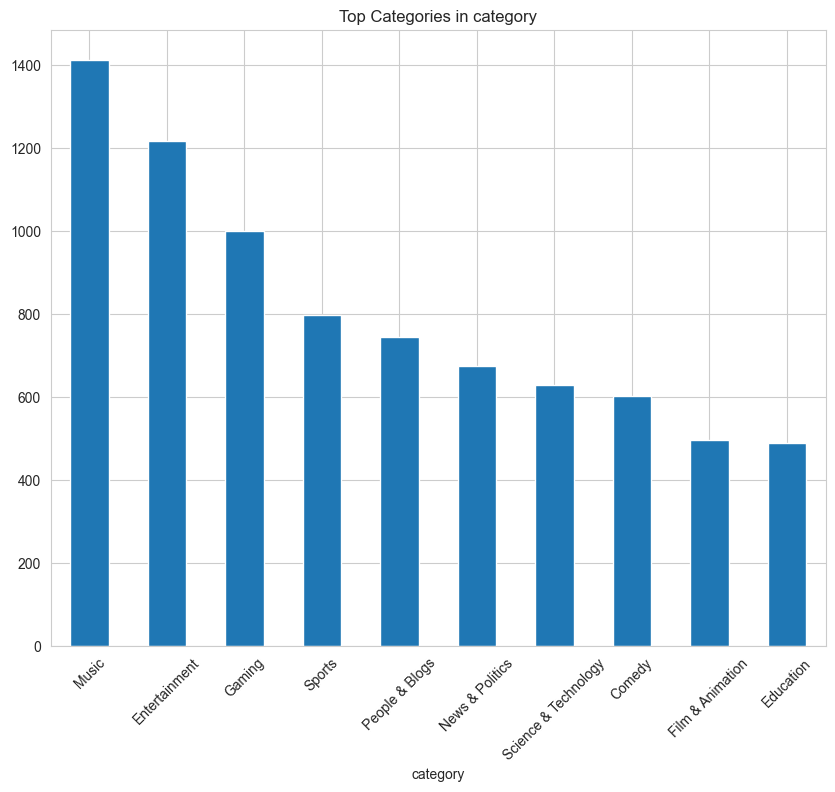

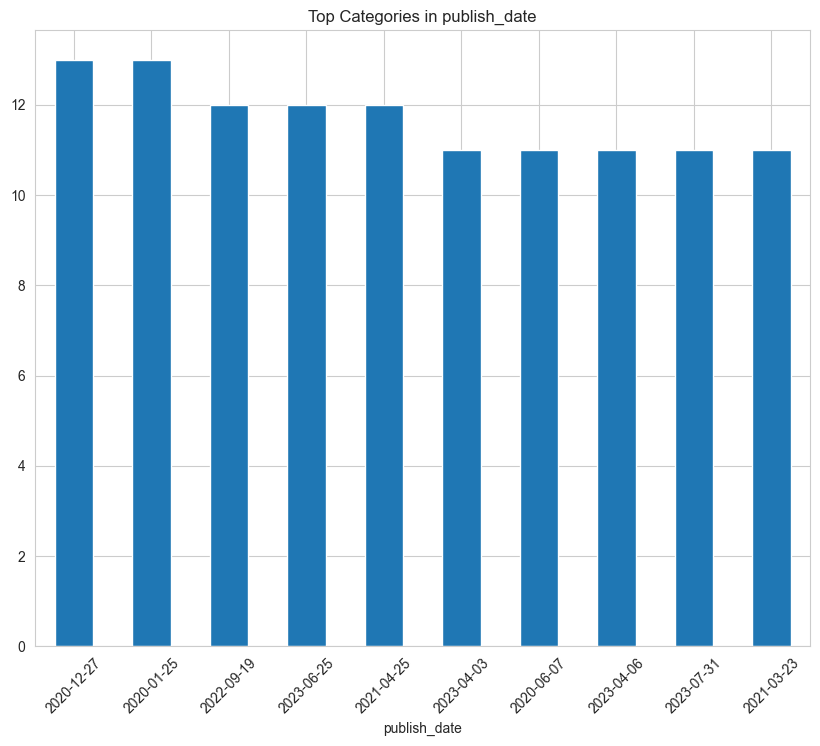

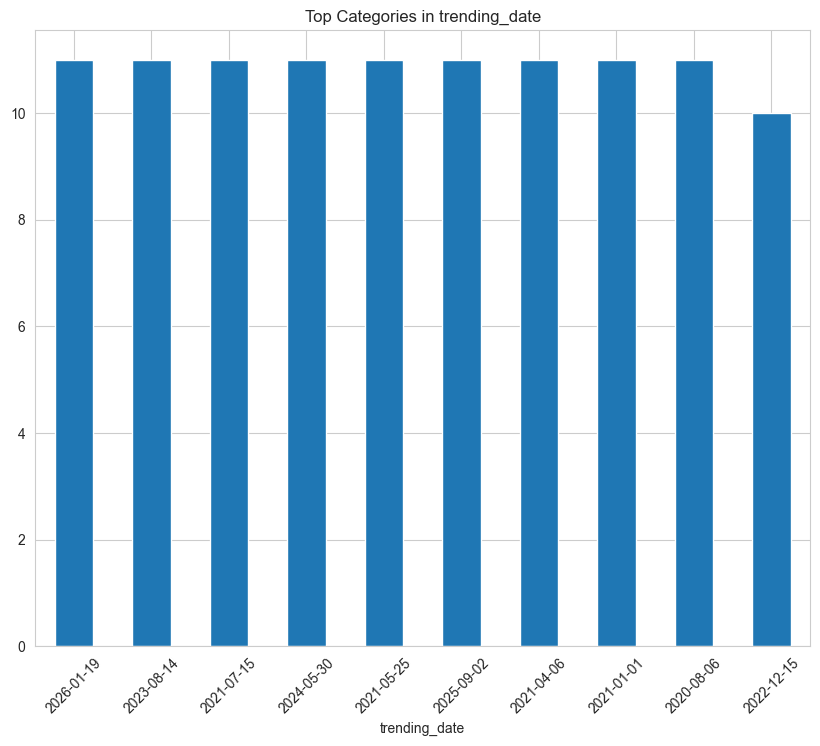

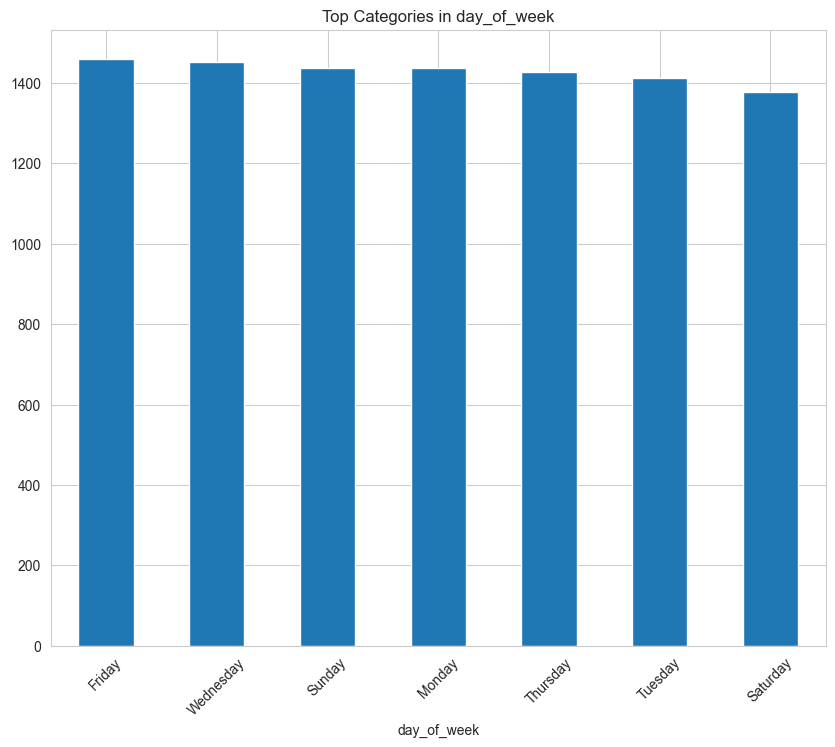

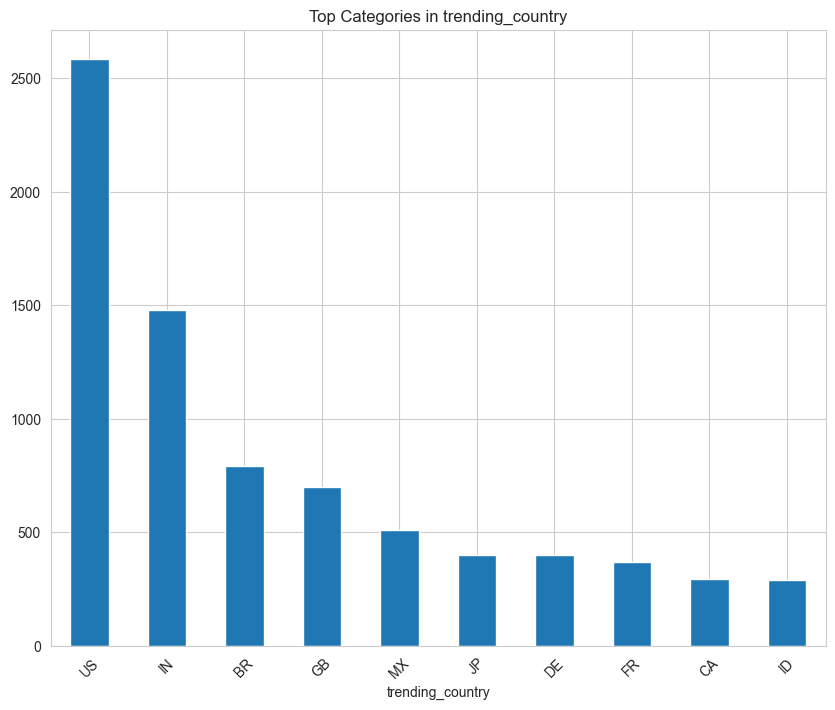

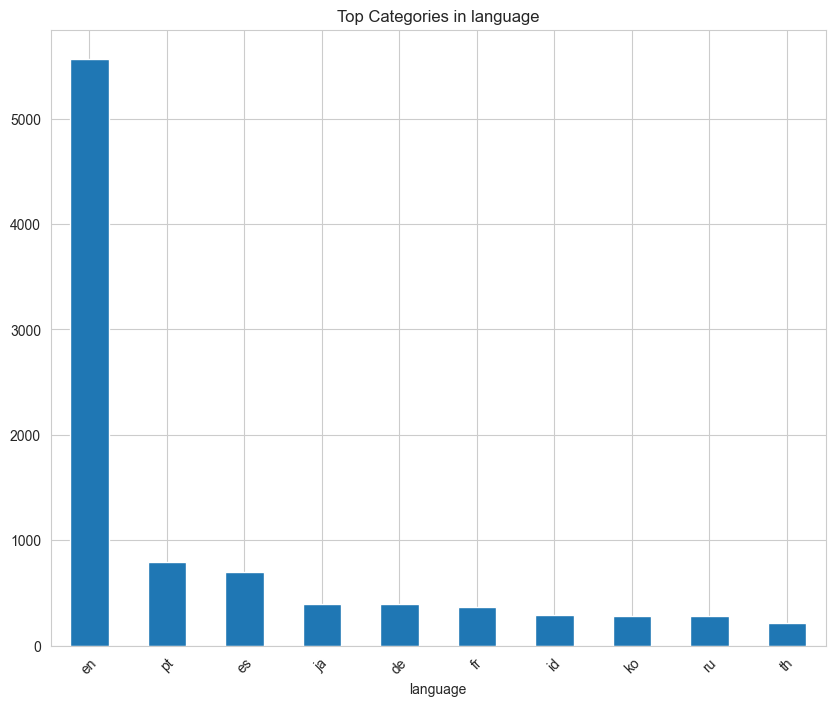

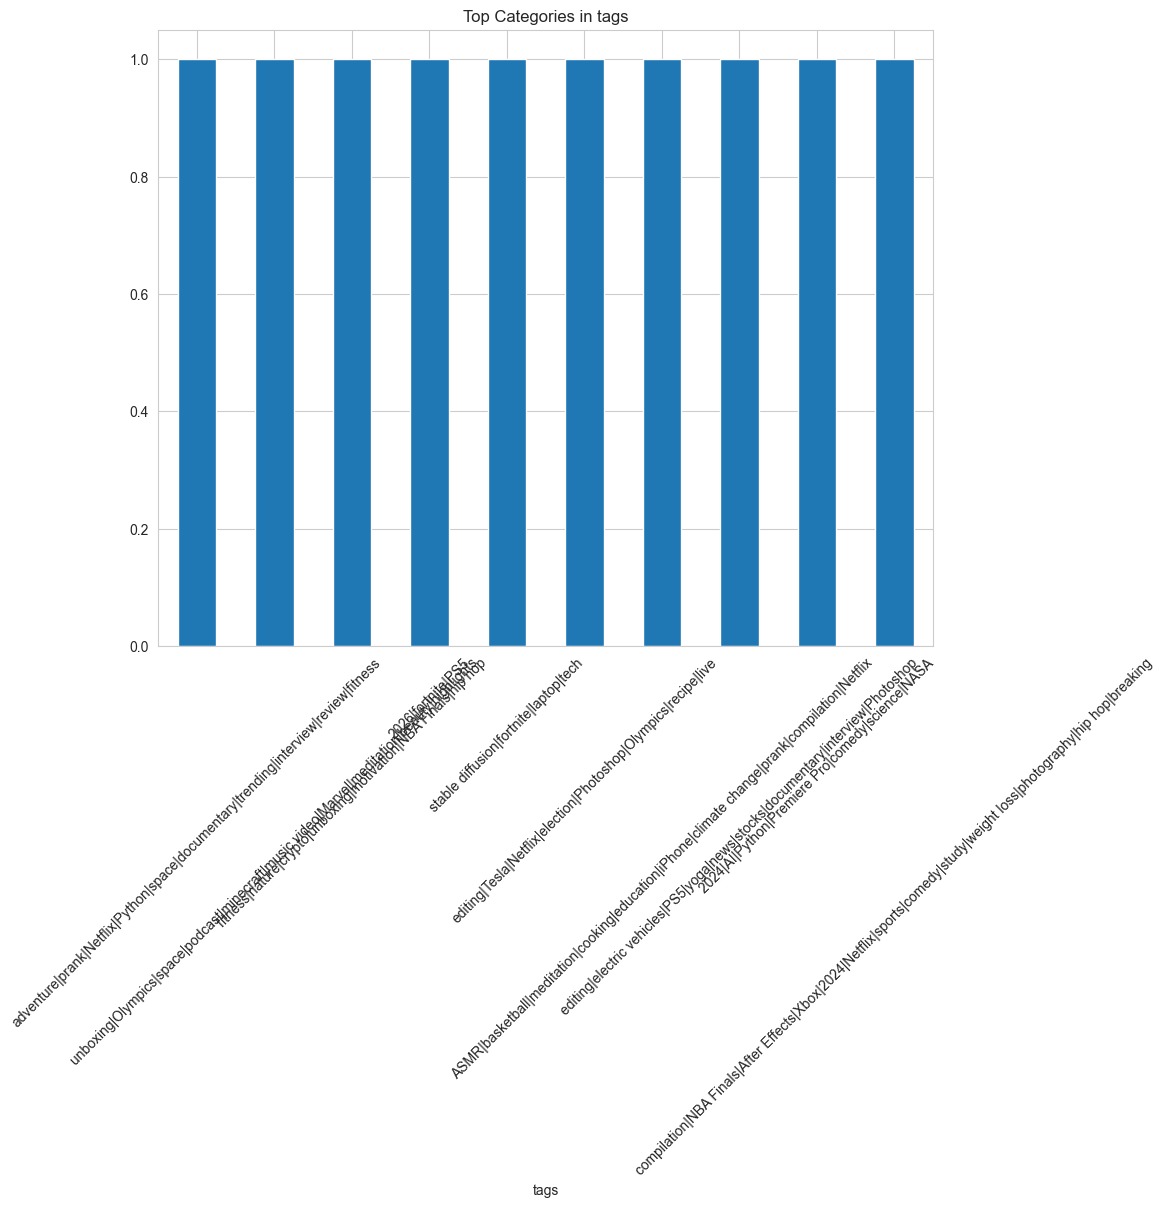

In [30]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()

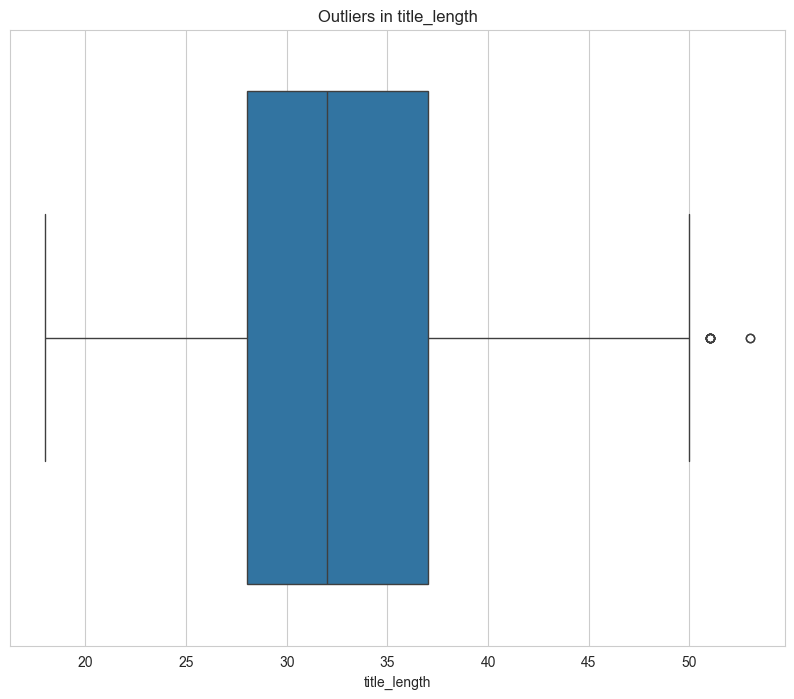

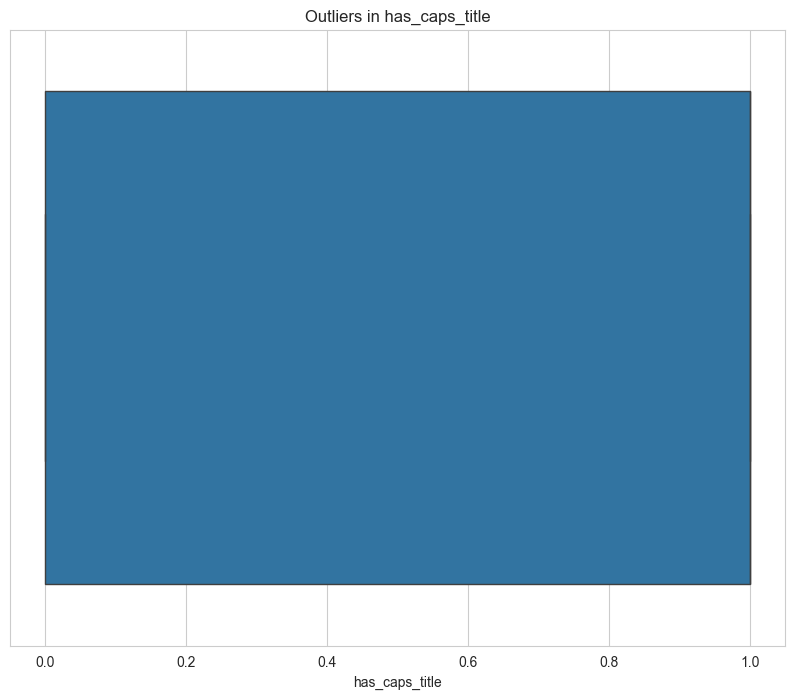

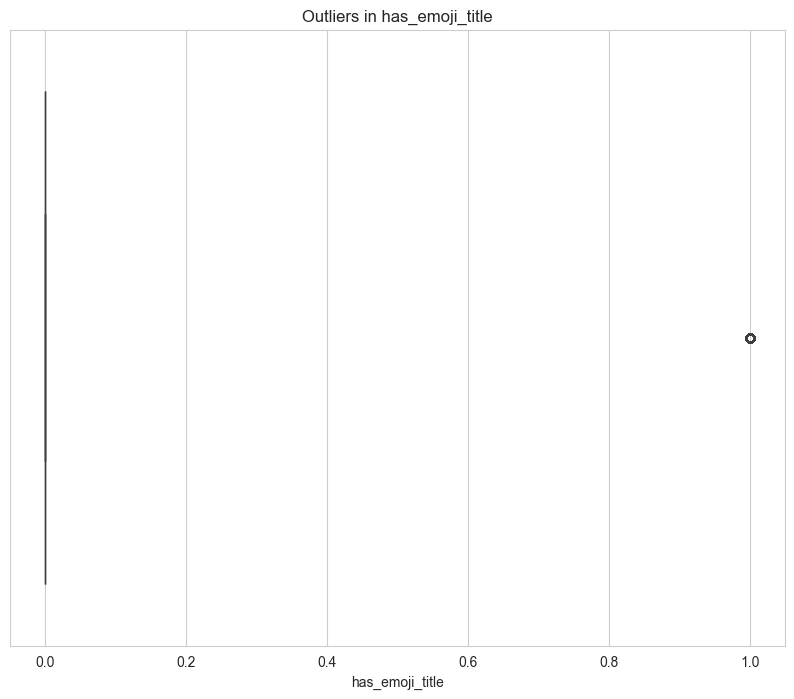

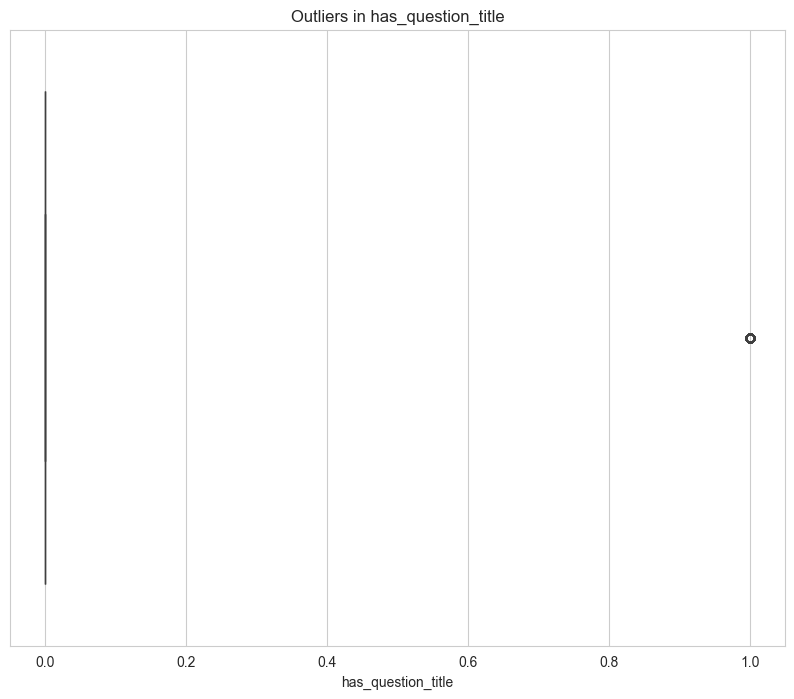

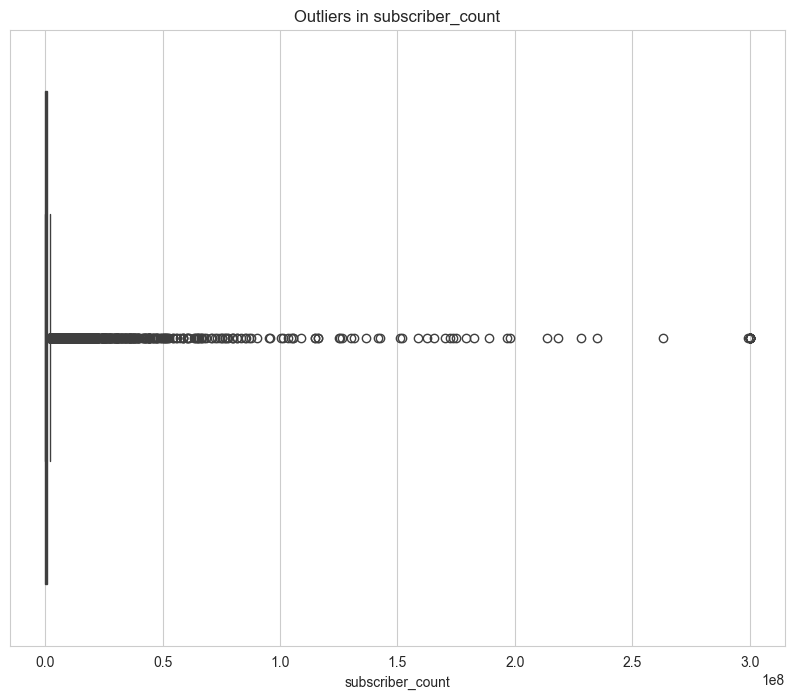

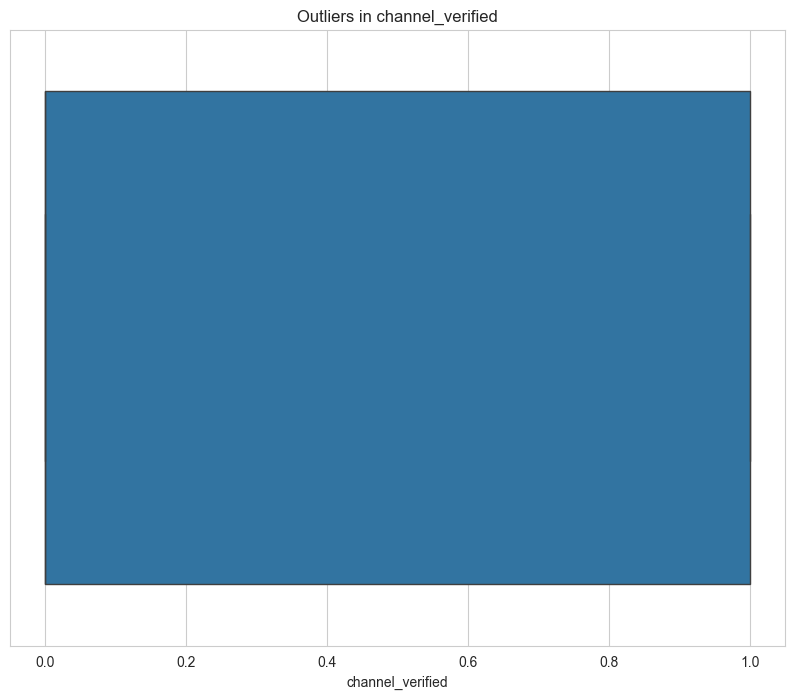

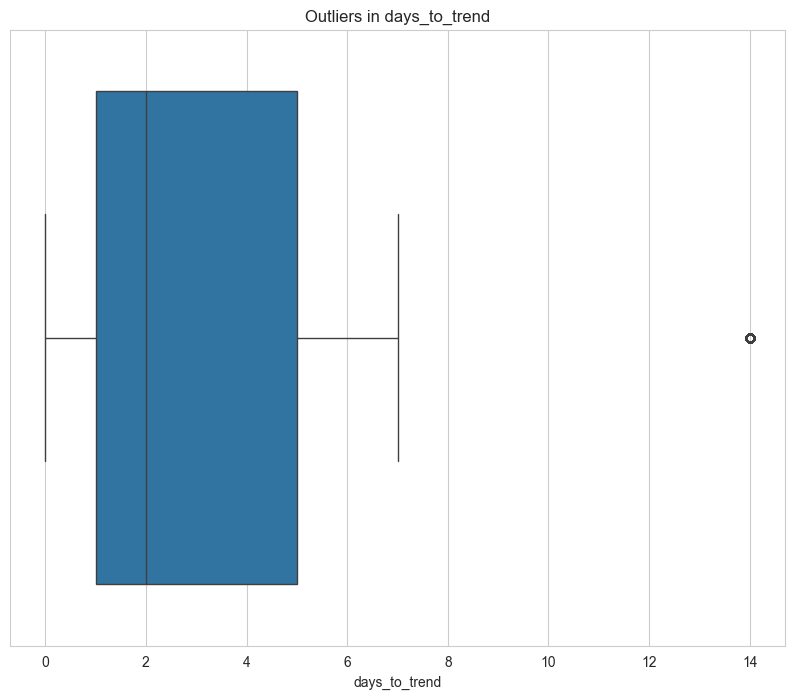

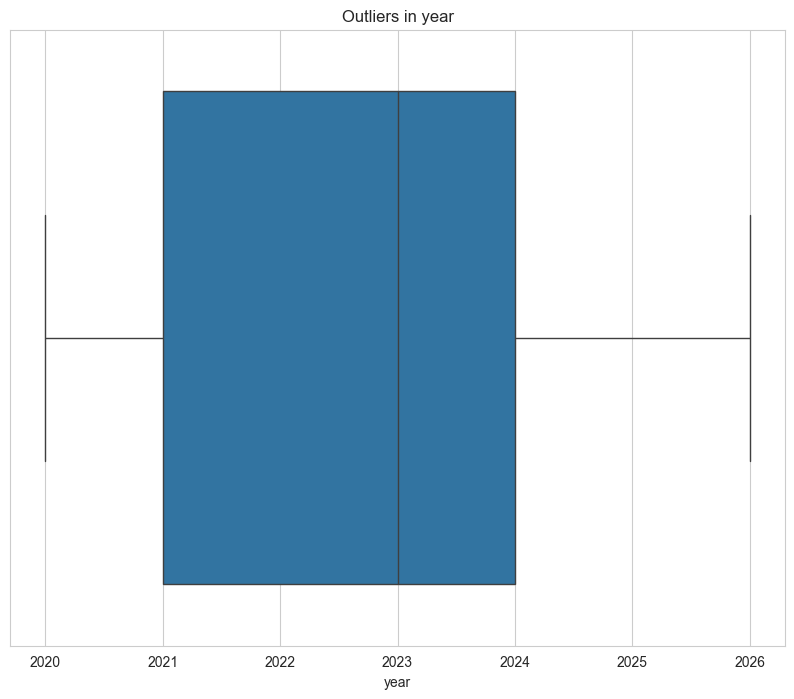

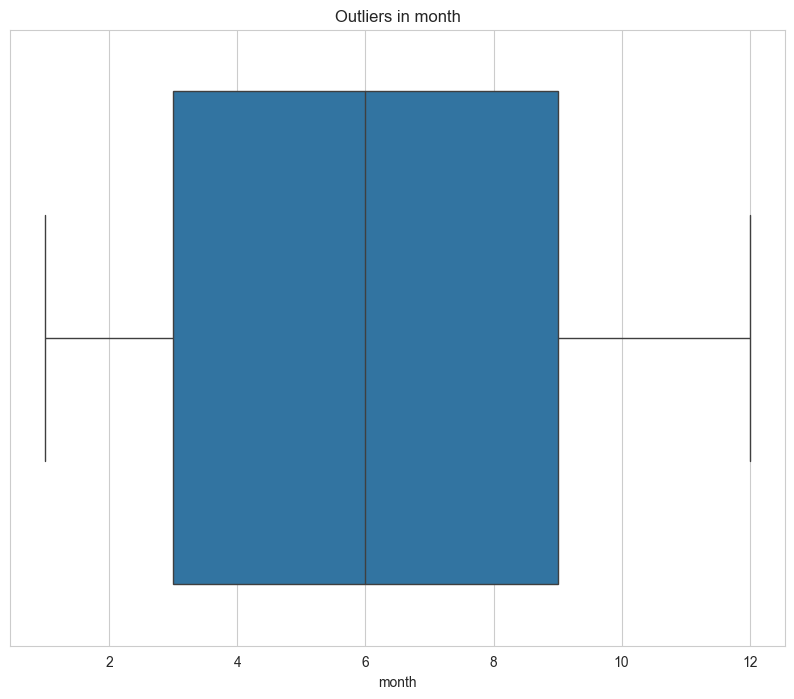

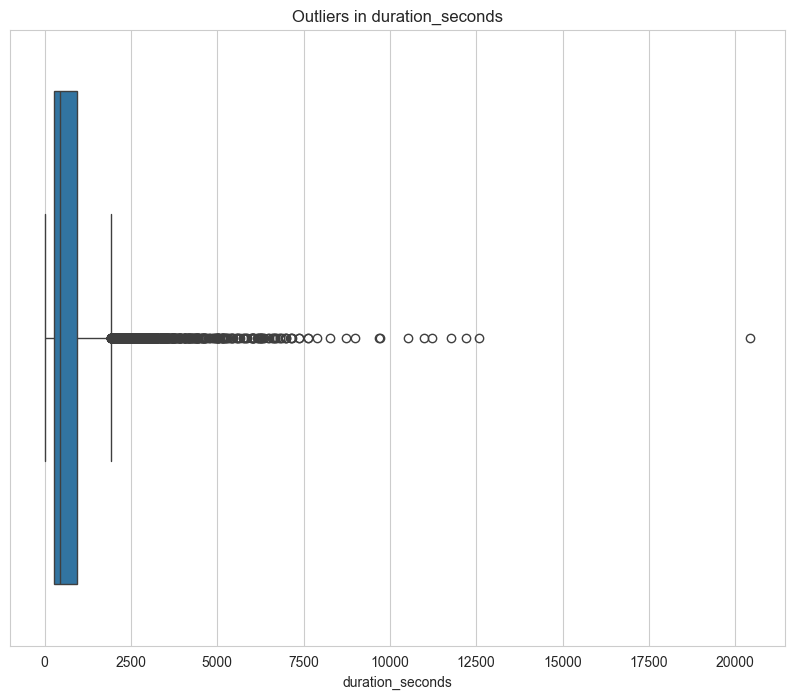

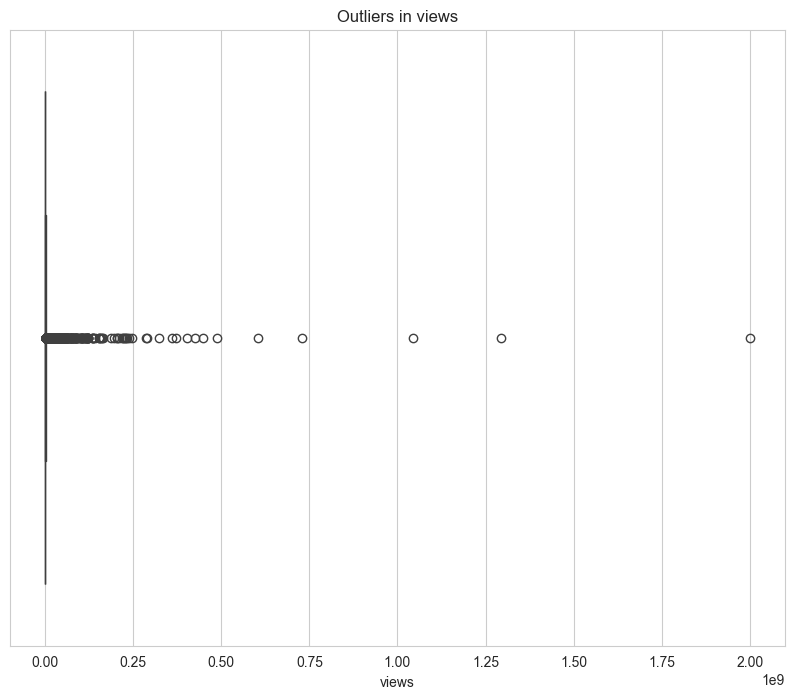

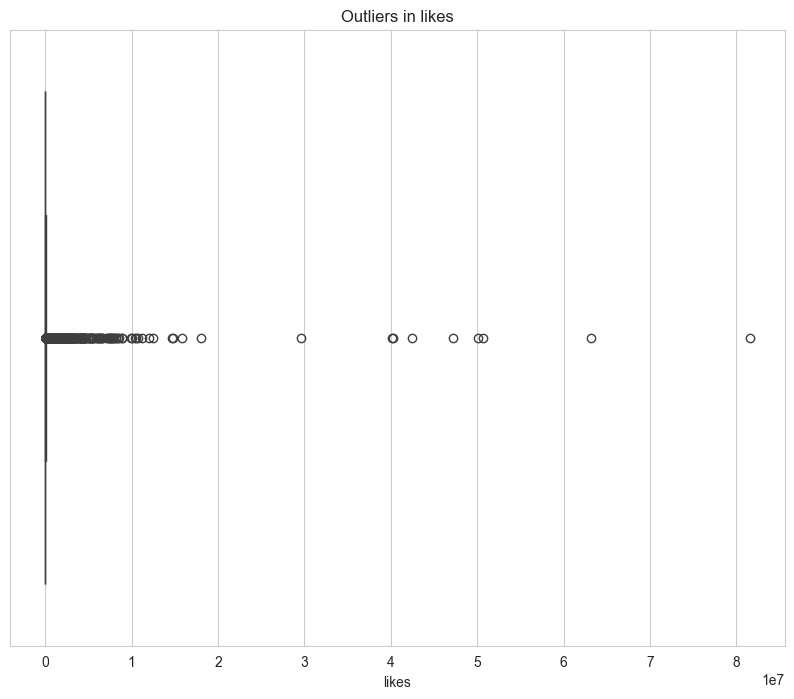

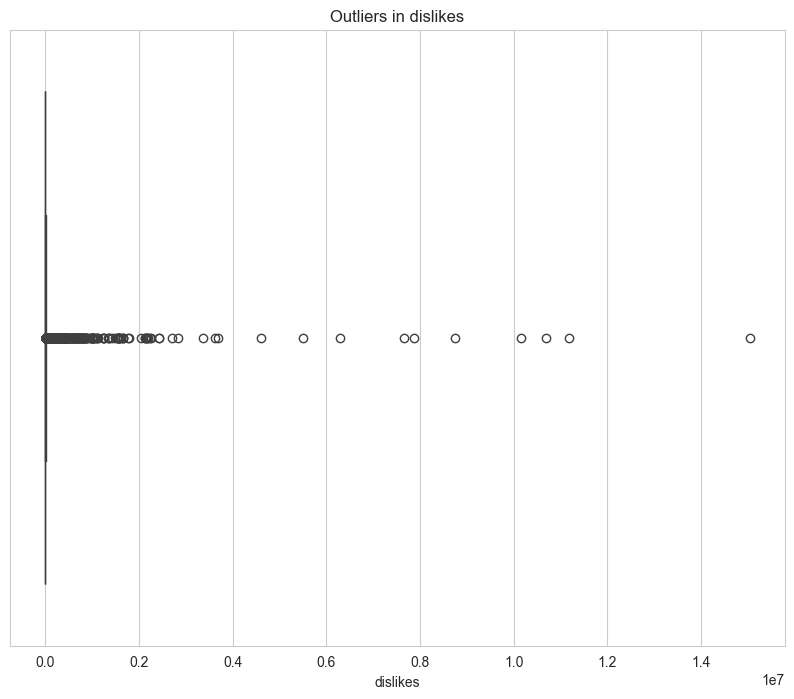

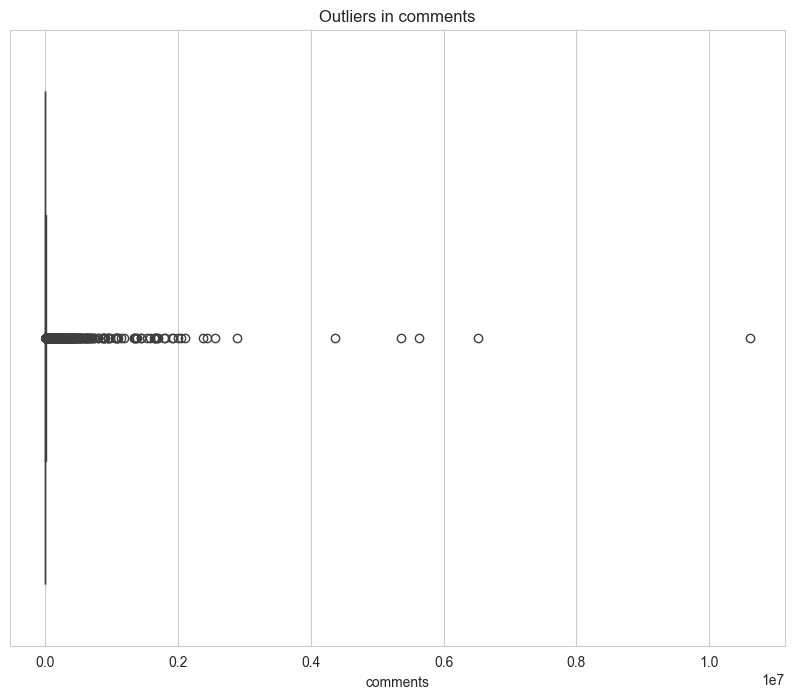

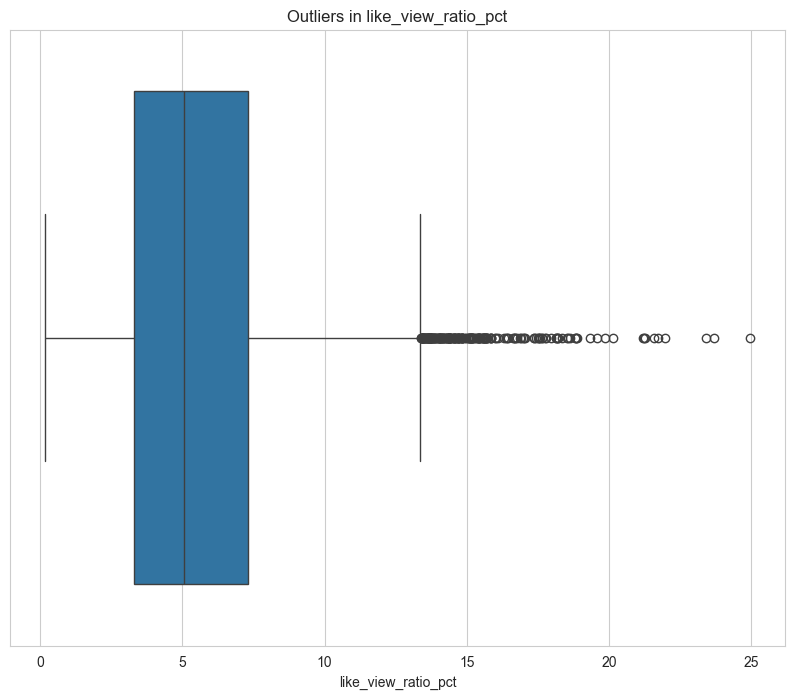

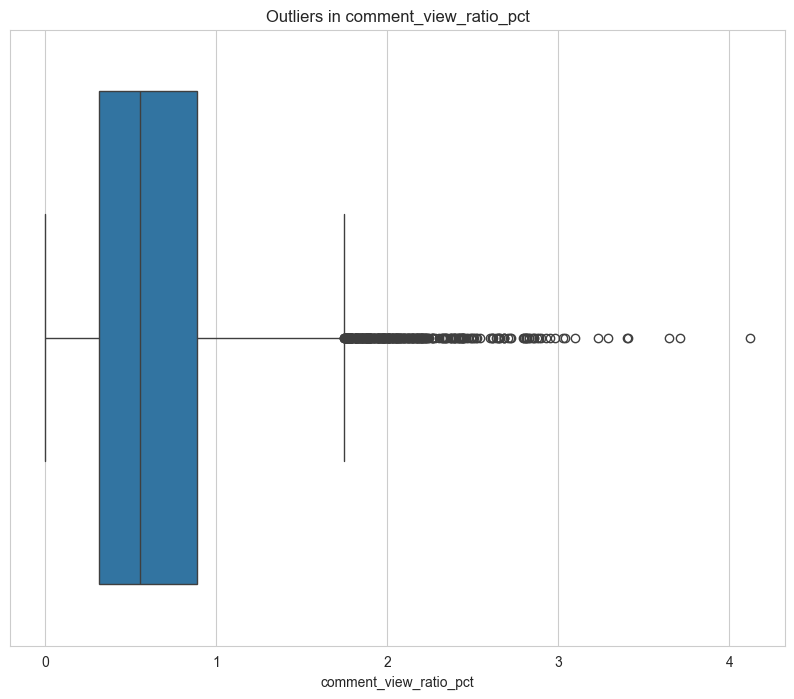

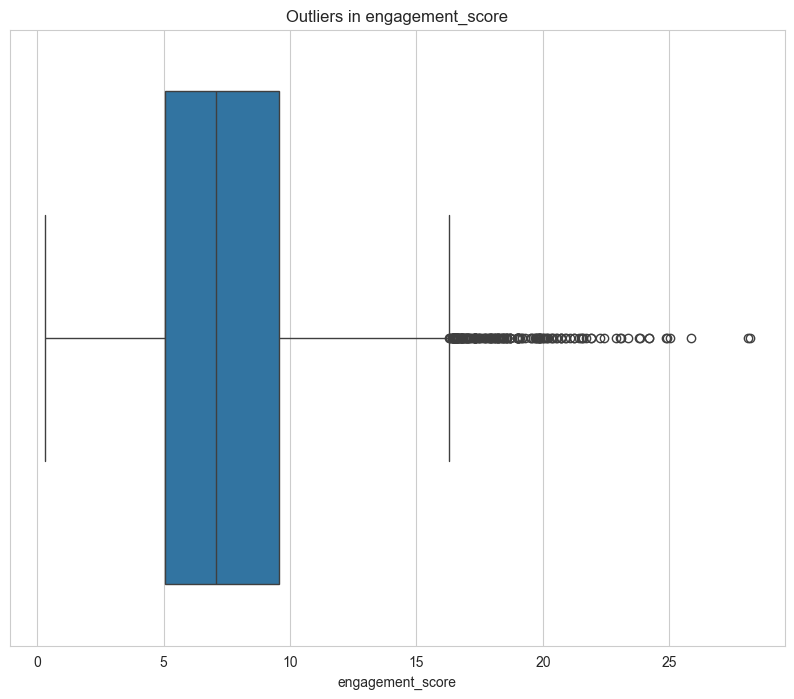

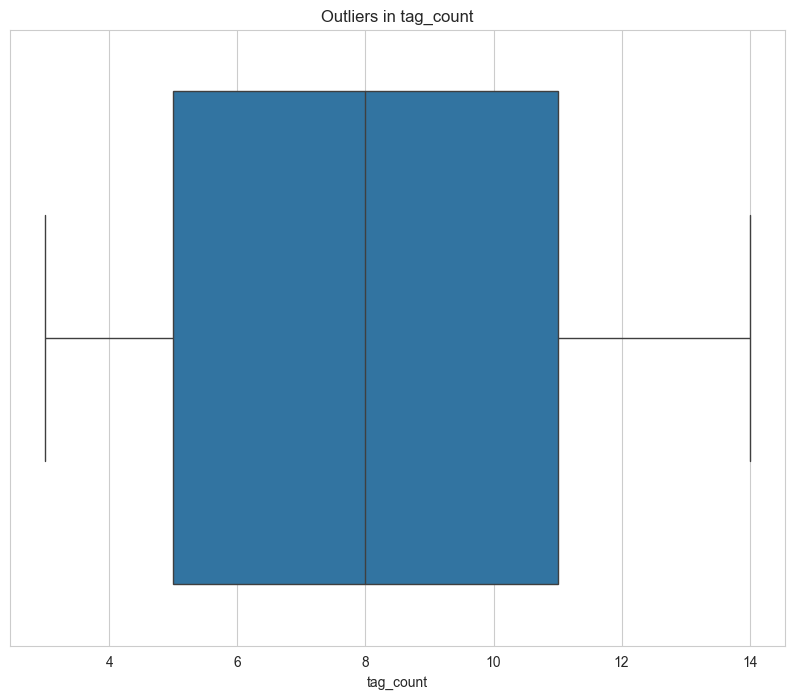

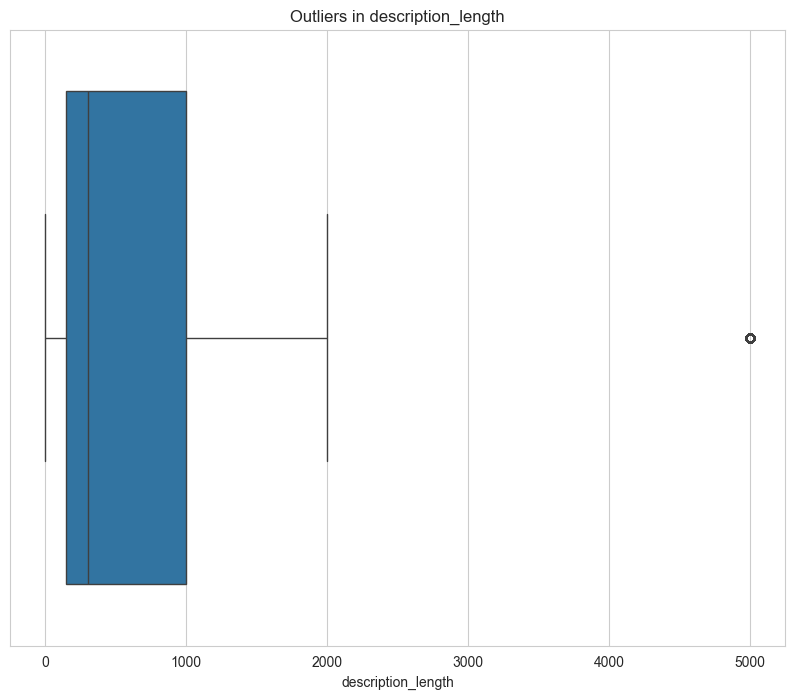

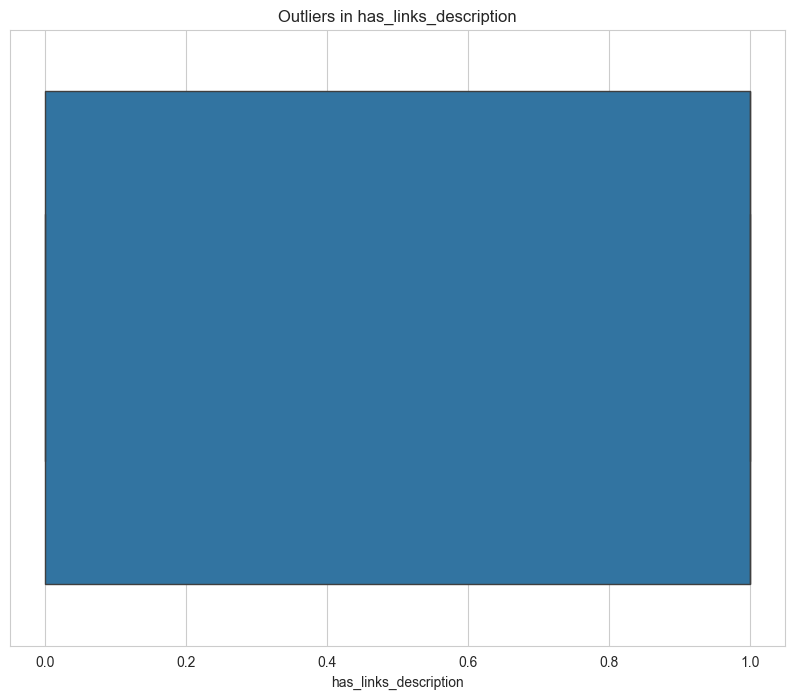

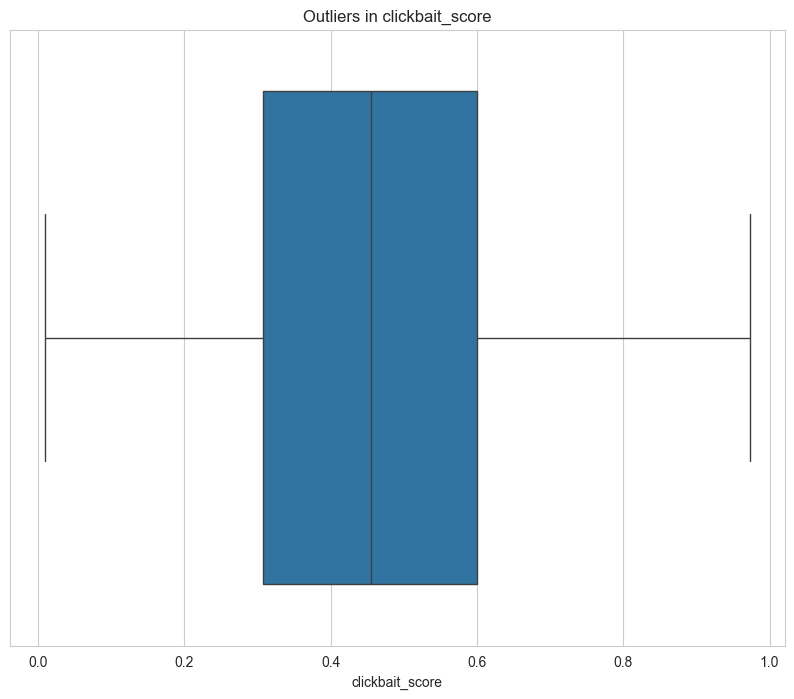

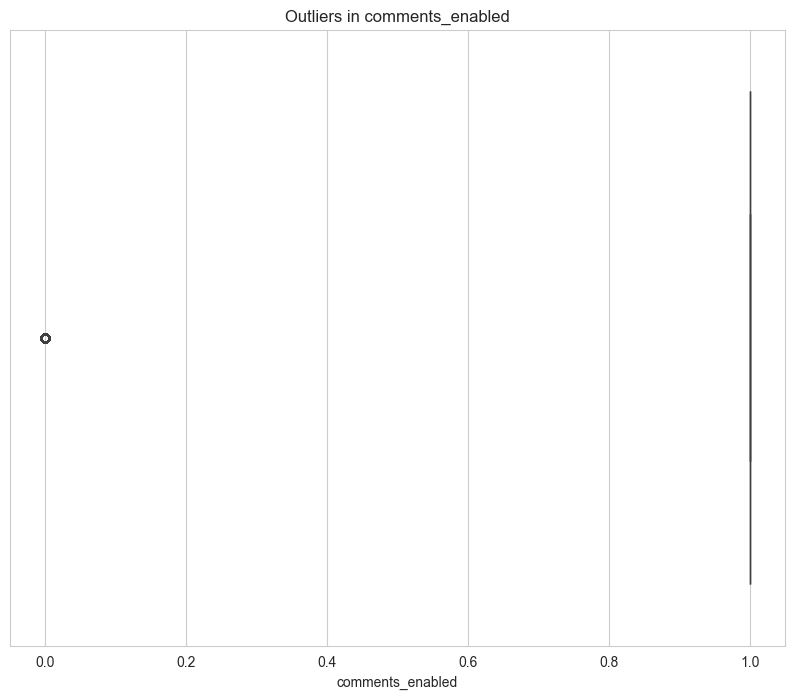

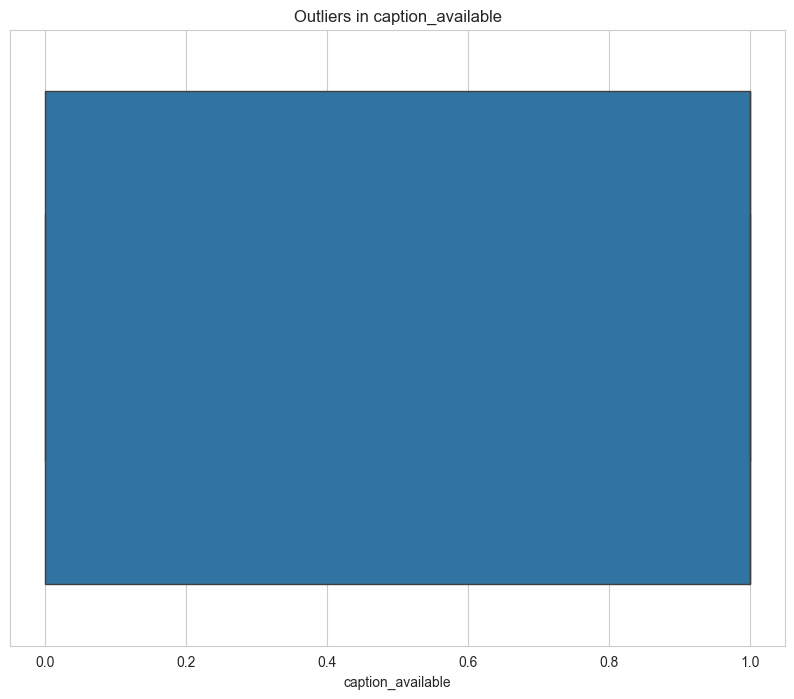

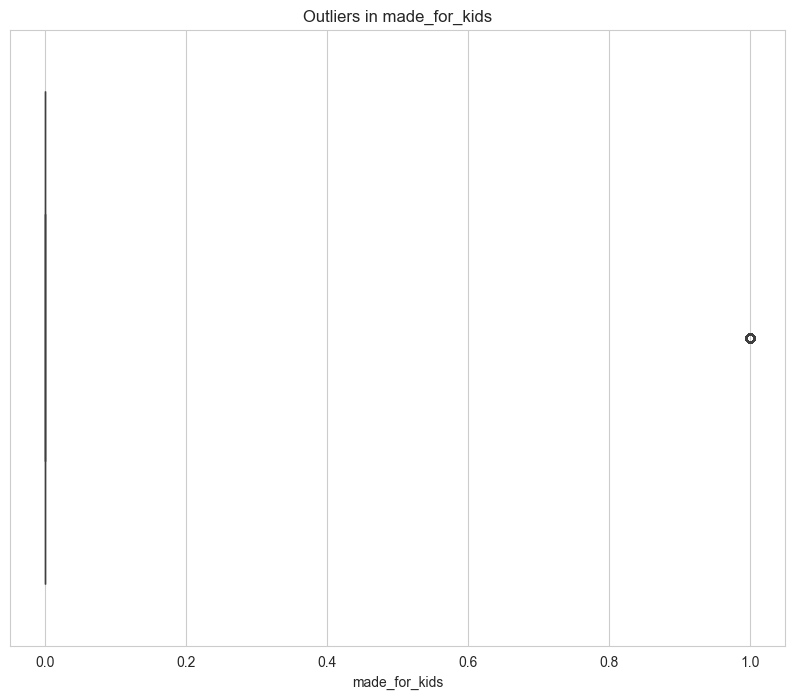

In [31]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [32]:
corr = df.corr(numeric_only=True)

corr

,title_length,has_caps_title,has_emoji_title,has_question_title,subscriber_count,channel_verified,days_to_trend,year,month,duration_seconds,...,like_view_ratio_pct,comment_view_ratio_pct,engagement_score,tag_count,description_length,has_links_description,clickbait_score,comments_enabled,caption_available,made_for_kids
title_length,1.000000,-0.189150,-0.188565,0.043436,-0.012762,0.007354,0.002925,-0.007575,0.020422,0.008627,...,-0.011230,-0.006453,-0.012810,-0.010154,0.010507,0.001721,0.004290,-0.001966,0.011317,-0.002940
has_caps_title,-0.189150,1.000000,0.126497,-0.069380,0.010479,-0.006686,0.011746,-0.007163,0.000011,-0.015899,...,-0.008150,-0.003260,-0.008716,-0.003545,-0.003653,0.006933,-0.017466,-0.003884,0.010233,0.116251
has_emoji_title,-0.188565,0.126497,1.000000,-0.019764,0.001561,-0.006691,0.007915,0.024066,-0.016140,-0.091489,...,0.015344,0.001216,0.014397,0.019770,-0.005555,0.007932,-0.005390,0.009983,-0.000245,-0.028130
has_question_title,0.043436,-0.069380,-0.019764,1.000000,0.011721,0.019590,-0.008700,-0.000028,-0.012245,0.018909,...,0.005338,-0.000089,0.004801,-0.002106,0.006459,0.013851,-0.003496,-0.011733,0.009471,-0.018163
subscriber_count,-0.012762,0.010479,0.001561,0.011721,1.000000,0.215468,0.000030,0.008982,0.000900,-0.002957,...,-0.000878,0.011436,0.003876,0.014981,-0.009266,-0.028892,-0.007833,-0.004570,0.006614,-0.016148
channel_verified,0.007354,-0.006686,-0.006691,0.019590,0.215468,1.000000,-0.003406,-0.005986,-0.006131,0.002765,...,-0.004247,-0.007134,-0.006762,-0.000208,0.000031,-0.008419,-0.002600,-0.006025,-0.005480,-0.012505
days_to_trend,0.002925,0.011746,0.007915,-0.008700,0.000030,-0.003406,1.000000,-0.013948,0.005169,-0.021391,...,0.011741,0.006971,0.013485,-0.016664,-0.005714,0.009442,0.016105,-0.000099,0.009914,0.005268
year,-0.007575,-0.007163,0.024066,-0.000028,0.008982,-0.005986,-0.013948,1.000000,-0.095203,0.011392,...,-0.007889,0.011340,-0.002515,-0.000841,-0.006165,0.016440,-0.002678,0.000622,-0.001468,0.007716
month,0.020422,0.000011,-0.016140,-0.012245,0.000900,-0.006131,0.005169,-0.095203,1.000000,-0.002372,...,0.008931,-0.002852,0.006926,-0.016443,0.008380,0.010521,-0.006800,0.005633,-0.012269,0.019396
duration_seconds,0.008627,-0.015899,-0.091489,0.018909,-0.002957,0.002765,-0.021391,0.011392,-0.002372,1.000000,...,0.007776,-0.007036,0.004171,-0.003792,-0.008433,-0.000776,0.000340,-0.000900,0.009903,-0.000643


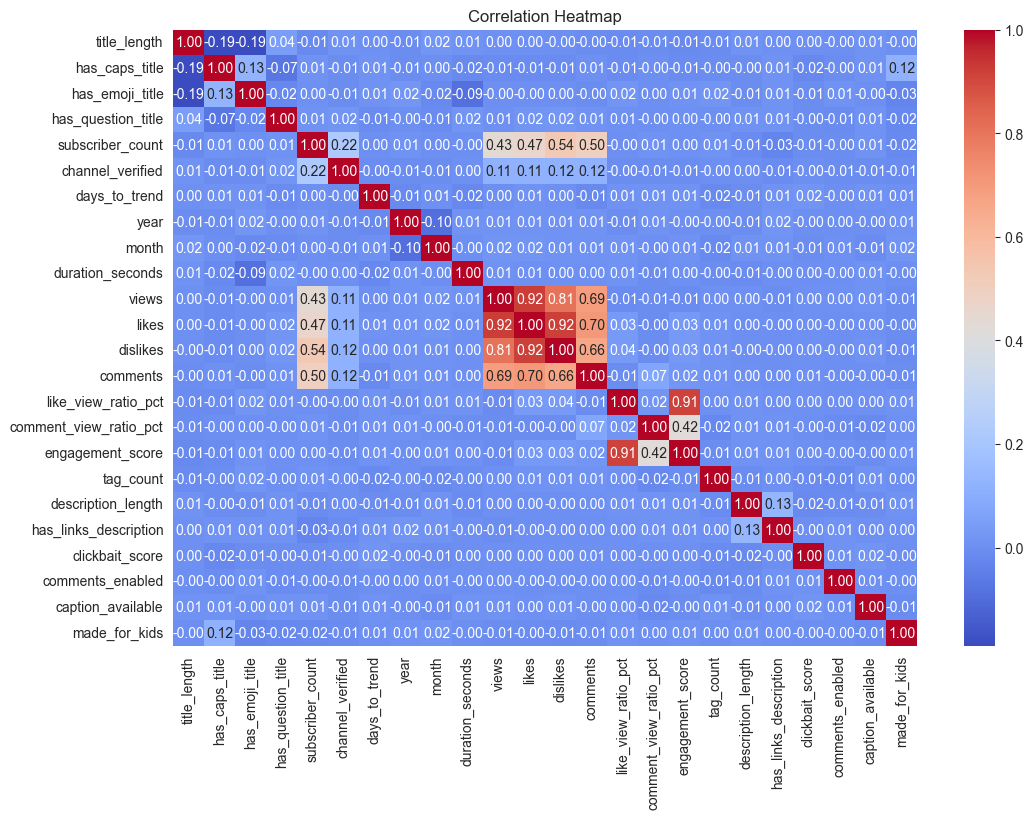

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

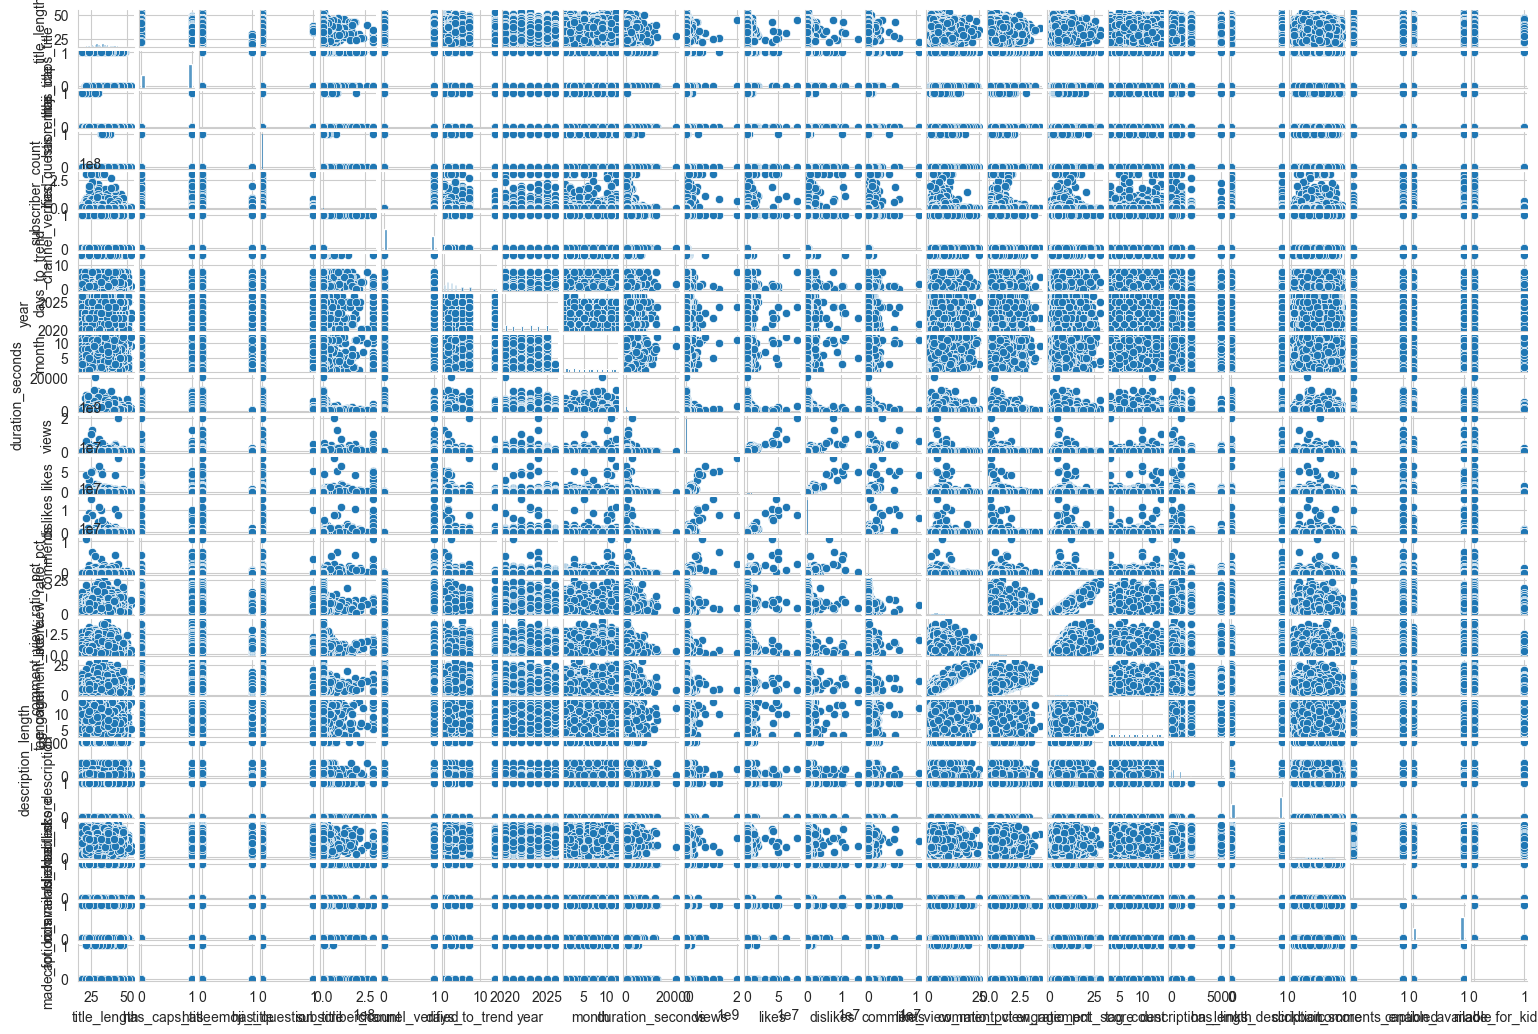

In [35]:
pp = sns.pairplot(df[num_cols])
pp.fig.set_size_inches(15, 10)

plt.show()